### Generic tutorial: light-based geolocation with `pangeo-fish`

**Overview.**

This notebook demonstrates the full `pangeo-fish` pipeline for archival DST tags from
Atlantic bluefin tuna (*Thunnus thynnus*).  It supports multiple tag manufacturers:

- **Lotek LAT2810** — semicolon-delimited CSV at 5 s resolution with raw light counts.
- **Wildlife Computers MiniPAT (PSAT)** — daily summary (DailyData.csv) with optional
  10-minute Series data for the last days before pop-up.

Configure `TAG_TYPE` and the paths in the **configuration cell** (Chapter 1).  The
rest of the notebook is tag-agnostic.  When `HAS_LIGHT = False` (e.g. PSAT with
insufficient raw-light data), Chapters 6 and 7 are skipped and only the
temperature-difference + bathymetry emission PDF is used for the HMM.

**Workflow.**

1. **Chapter 0** — Ingest raw manufacturer CSV → standard `(time, temperature, pressure, light)` table.
2. **Chapter 1** — Configuration, cluster, tag DataTree.
3. **Chapter 2** — Temperature-difference emission PDF.
4. **Chapter 3** — HEALPix regridding.
5. **Chapter 4** — Compute emission PDF.
6. **Chapter 5** — Bathymetry PDF.
7. **Chapter 6** — *(if HAS_LIGHT)* Solar threshold PDF.
8. **Chapter 7** — *(if HAS_LIGHT)* Lunar template-fit PDF.
9. **Chapter 8** — Merge all emission PDFs.
10. **Chapter 9** — HMM trajectory decoding.

## 0. Raw data ingestion

Read the raw manufacturer file(s) and convert to the standard
`(time, temperature, pressure, light)` DataFrame used by the pipeline.
The result is stored in a `tag` DataTree with the same structure as
`pangeo_fish.io.open_tag`, so all downstream cells work unchanged.

In [7]:
from pangeo_fish.helpers import load_tag

tag, tag_log, time_slice = load_tag(
    tag_root=TAG_ROOT,
    tag_name=tag_name,
    raw_csv_path=RAW_DATA_PATH,
    tag_type=TAG_TYPE,
    tagging_events_path=TAGGING_EVENTS_PATH,
)
print(f'Deployment: {time_slice.start} → {time_slice.stop}')
tag


  12,139,475 rows | 2023-11-03 22:45:10 → 2025-10-06 11:08:00


,temperature,pressure,light
time,,,
2023-11-03 22:45:10,20.58,0.0,85
2023-11-03 22:45:15,20.58,0.0,266
2023-11-03 22:45:20,20.58,0.0,266


In [29]:
# tag, tag_log, time_slice ready


tag_log: 11,257,849 timesteps


<xarray.DataTree>
Group: /
│   Attributes:
│       tag_name:  281B-4949
│       tag_type:  lotek
├── Group: /dst
│       Dimensions:      (time: 12139475)
│       Coordinates:
│         * time         (time) datetime64[ns] 97MB 2023-11-03T22:45:10 ... 2025-10-0...
│       Data variables:
│           temperature  (time) float64 97MB 20.58 20.58 20.58 ... 23.28 23.3 23.28
│           pressure     (time) float64 97MB 0.0 0.0 0.0 0.0 0.0 ... 7.25 6.25 6.25 5.25
│           light        (time) int64 97MB 85 266 266 279 254 ... 322 318 319 322 322
└── Group: /tagging_events
        Dimensions:     (event_name: 2)
        Coordinates:
          * event_name  (event_name) object 16B 'release' 'fish_death'
        Data variables:
            time        (event_name) datetime64[ns] 16B 2023-11-04T12:06:00 2025-08-17
            longitude   (event_name) float64 16B 0.8583 0.7146
            latitude    (event_name) float64 16B 40.88 40.81

## 1. Initialization and configuration definition

In this step, we prepare the execution of the analysis.
It includes:
- Installing the necessary packages.
- Importing the required libraries.
- Defining the parameters for the next stages of the workflow.
- Configuring the cluster for distributed computing.
    

In [9]:
import sys

import hvplot.xarray
import xarray as xr
from pint_xarray import unit_registry as ureg

sys.path.append("../")
import pangeo_fish

In [10]:
import pandas as pd
from pint_xarray import unit_registry as ureg

# ══════════════════════════════════════════════════════════════════════════════
# TAG CONFIGURATION — uncomment ONE block below
# ══════════════════════════════════════════════════════════════════════════════

# ── Option A: Lotek LAT2810 (281B-4949) — 22 months, NW Mediterranean ────────
TAG_TYPE              = "lotek"
tag_name              = "281B-4949"
# RAW_DATA_PATH         = "/path/to/281B-4949_Basic Log_1.csv"
# TAGGING_EVENTS_PATH   = "/path/to/281B-4949_tagging_events.csv"
HAS_LIGHT             = True

bbox = {"latitude": [34.0, 48.0], "longitude": [-6.0, 20.0], "max_depth": 450}

# ── Option B: WC MiniPAT (263936) — Bay of Biscay / Atlantic ─────────────────
# TAG_TYPE              = "wc_psat"
# tag_name              = "263936"
# RAW_DATA_PATH         = "/path/to/263936-Series.csv"
# TAGGING_EVENTS_PATH   = "/path/to/263936_tagging_events.csv"
# HAS_LIGHT             = False   # no raw light counts in WC Series; skip Ch6/Ch7
#
# bbox = {"latitude": [25.0, 55.0], "longitude": [-55.0, 20.0], "max_depth": 700}

# ── Storage & compute ─────────────────────────────────────────────────────────
scratch_root = "s3://gfts-ifremer/tuna/run/capetienne/generic"
storage_options = {
    "anon": False,
    "profile": "gfts",
    "client_kwargs": {
        "endpoint_url": "https://s3.gra.perf.cloud.ovh.net",
        "region_name": "gra",
    },
}

chunk_time = 1
dims = ["cells"]

# HEALPix grid
rot              = {"lat": 0, "lon": 0}
nside            = 256
refinement_level = 8
min_vertices     = 1

# Emission PDF
differences_std = 1.0
initial_std     = 1e-3
recapture_std   = 1e-3

# HMM
earth_radius             = ureg.Quantity(6371, "km")
maximum_speed            = ureg.Quantity(5, "km / hour")
tolerance                = 1e-4
track_modes              = ["mean", "mode"]
additional_track_quantities = ["speed", "distance"]


In [11]:
target_root = f"{scratch_root}/{tag_name}"

default_chunk      = {"time": chunk_time, "lat": -1, "lon": -1}
default_chunk_dims = {"time": chunk_time}
default_chunk_dims.update({d: -1 for d in dims})

In [12]:
target_root

's3://gfts-ifremer/tuna/run/capetienne/generic/281B-4949'

In [13]:
# Set up a local cluster for distributed computing.
from distributed import LocalCluster

cluster = LocalCluster()
client = cluster.get_client()
client

/home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44039 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:44039/status,
Dashboard: http://127.0.0.1:44039/status,Workers: 4
Total threads: 16,Total memory: 24.45 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45693,Workers: 0
Dashboard: http://127.0.0.1:44039/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36387,Total threads: 4
Dashboard: http://127.0.0.1:46789/status,Memory: 6.11 GiB
Nanny: tcp://127.0.0.1:38193,


2026-04-13 17:18:14,507 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 32e7b8c5b267708bbe608334fdf46841 initialized by task ('rechunk-merge-rechunk-transfer-ea78f54f2fc69f3ca50257f9044a3980', 0, 0, 0, 0, 0, 0, 9, 9) executed on worker tcp://127.0.0.1:42547


Now that everything is set up, we can start by loading the biologging data (or _tag_)

In [14]:
# tag, tag_log, time_slice built in Chapter 0 above.
tag

<xarray.DataTree>
Group: /
│   Attributes:
│       tag_name:  281B-4949
│       tag_type:  lotek
├── Group: /dst
│       Dimensions:      (time: 12139475)
│       Coordinates:
│         * time         (time) datetime64[ns] 97MB 2023-11-03T22:45:10 ... 2025-10-0...
│       Data variables:
│           temperature  (time) float64 97MB 20.58 20.58 20.58 ... 23.28 23.3 23.28
│           pressure     (time) float64 97MB 0.0 0.0 0.0 0.0 0.0 ... 7.25 6.25 6.25 5.25
│           light        (time) int64 97MB 85 266 266 279 254 ... 322 318 319 322 322
└── Group: /tagging_events
        Dimensions:     (event_name: 2)
        Coordinates:
          * event_name  (event_name) object 16B 'release' 'fish_death'
        Data variables:
            time        (event_name) datetime64[ns] 16B 2023-11-04T12:06:00 2025-08-17
            longitude   (event_name) float64 16B 0.8583 0.7146
            latitude    (event_name) float64 16B 40.88 40.81

You can plot the time series of the DST with the function `plot_tag()`:

## 2. Compare the reference data with the DST logs

In this step, we compare the reference model data with Data Storage Tag information.
The process involves reading and cleaning the reference model, aligning time, converting depth units and subtracting the tag data from the model.
We also illustrate how to plot and saving the result.

In [15]:
import copernicusmarine
import xarray as xr
from pangeo_fish.io import prepare_dataset

ds_thetao_zos = copernicusmarine.open_dataset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
    variables=["thetao", "zos"],
    minimum_longitude=bbox["longitude"][0],
    maximum_longitude=bbox["longitude"][1],
    minimum_latitude=bbox["latitude"][0],
    maximum_latitude=bbox["latitude"][1],
    start_datetime=time_slice.start.strftime("%Y-%m-%d"),
    end_datetime=time_slice.stop.strftime("%Y-%m-%d"),
)

static_var = copernicusmarine.open_dataset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_static",
    variables=["deptho", "mask"],
    minimum_longitude=bbox["longitude"][0],
    maximum_longitude=bbox["longitude"][1],
    minimum_latitude=bbox["latitude"][0],
    maximum_latitude=bbox["latitude"][1],
)


/home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/movingpandas/__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)
INFO - 2026-04-13T17:16:48Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:

  etienne.cap@ifremer.fr


Copernicus Marine password:

  ········


...

Copernicus Marine username:

  etienne.cap@ifremer.fr


Copernicus Marine password:

  ········


INFO - 2026-04-13T17:17:11Z - Selected dataset version: "202311"
INFO - 2026-04-13T17:17:11Z - Selected dataset part: "bathy"


In [16]:
static_var = static_var.assign_coords(longitude=ds_thetao_zos["longitude"].values)

In [17]:
ds_all = xr.merge([ds_thetao_zos, static_var], compat="no_conflicts")
ds_all = ds_all.rename({"latitude": "lat", "longitude": "lon"})
model = prepare_dataset(ds_all)
model

<xarray.Dataset> Size: 28GB
Dimensions:             (depth: 50, lat: 169, lon: 313, time: 653)
Coordinates:
  * depth               (depth) float32 200B 0.494 1.541 ... 5.275e+03 5.728e+03
  * lat                 (lat) float32 676B 34.0 34.08 34.17 ... 47.83 47.92 48.0
  * lon                 (lon) float32 1kB -6.0 -5.917 -5.833 ... 19.92 20.0
    latitude            (lat, lon) float32 212kB 34.0 34.0 34.0 ... 48.0 48.0
    longitude           (lat, lon) float32 212kB -6.0 -5.917 ... 19.92 20.0
  * time                (time) datetime64[ns] 5kB 2023-11-04 ... 2025-08-17
Data variables:
    TEMP                (time, depth, lat, lon) float64 14GB dask.array<chunksize=(8, 11, 169, 313), meta=np.ndarray>
    XE                  (time, lat, lon) float64 276MB dask.array<chunksize=(8, 169, 313), meta=np.ndarray>
    H0                  (lat, lon) float32 212kB dask.array<chunksize=(169, 313), meta=np.ndarray>
    mask                (depth, lat, lon) int8 3MB dask.array<chunksize=(11, 169, 313), meta=np.ndarray>
    dynamic_depth       (depth, time, lat, lon) float64 14GB dask.array<chunksize=(50, 8, 169, 313), meta=np.ndarray>
    dynamic_bathymetry  (lat, lon, time) float64 276MB dask.array<chunksize=(169, 313, 8), meta=np.ndarray>
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min:                     0.49402499198913574
    copernicusmarine_version:  2.3.0

In [31]:
model = xr.open_dataset(
    f"{target_root}/model_variance.zarr", engine="zarr",
    chunks={"time": 8, "depth": -1, "lat": 100, "lon": 100},
    storage_options=storage_options,
)
model

<xarray.Dataset> Size: 28GB
Dimensions:             (lat: 169, lon: 313, time: 653, depth: 50)
Coordinates:
  * lat                 (lat) float32 676B 34.0 34.08 34.17 ... 47.83 47.92 48.0
  * lon                 (lon) float32 1kB -6.0 -5.917 -5.833 ... 19.92 20.0
    latitude            (lat, lon) float32 212kB dask.array<chunksize=(100, 100), meta=np.ndarray>
    longitude           (lat, lon) float32 212kB dask.array<chunksize=(100, 100), meta=np.ndarray>
  * time                (time) datetime64[ns] 5kB 2023-11-04 ... 2025-08-17
  * depth               (depth) float32 200B 0.494 1.541 ... 5.275e+03 5.728e+03
Data variables:
    dynamic_bathymetry  (lat, lon, time) float64 276MB dask.array<chunksize=(100, 100, 8), meta=np.ndarray>
    dynamic_depth       (depth, time, lat, lon) float64 14GB dask.array<chunksize=(50, 8, 100, 100), meta=np.ndarray>
    H0                  (lat, lon) float32 212kB dask.array<chunksize=(100, 100), meta=np.ndarray>
    mask                (depth, lat, lon) int8 3MB dask.array<chunksize=(50, 100, 100), meta=np.ndarray>
    TEMP                (time, depth, lat, lon) float64 14GB dask.array<chunksize=(8, 50, 100, 100), meta=np.ndarray>
    XE                  (time, lat, lon) float64 276MB dask.array<chunksize=(8, 100, 100), meta=np.ndarray>
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min:                     0.49402499198913574
    copernicusmarine_version:  2.3.0

In [32]:
import pandas as pd
from pangeo_fish.cf import bounds_to_bins
from pangeo_fish.tags import adapt_model_time, reshape_by_bins, to_time_slice

tag_log["time"] = tag_log["time"].dt.floor("D")
start = pd.Timestamp(tag_log["time"].min().item())
end = pd.Timestamp(tag_log["time"].max().item())

extended_time_slice = slice(start, end)

reference_model = (
    model.sel(time=adapt_model_time(extended_time_slice))
    .sel(lat=slice(*bbox["latitude"]), lon=slice(*bbox["longitude"]))
    .pipe(
        lambda ds: ds.sel(
            depth=slice(None, (tag_log["pressure"].max() + 100).compute())
        )
    )
).chunk({"time": 1,
    "depth": -1,
    "lat": 100,
    "lon": 100})



reference_model

<xarray.Dataset> Size: 19GB
Dimensions:             (lat: 169, lon: 313, time: 653, depth: 33)
Coordinates:
  * lat                 (lat) float32 676B 34.0 34.08 34.17 ... 47.83 47.92 48.0
  * lon                 (lon) float32 1kB -6.0 -5.917 -5.833 ... 19.92 20.0
    latitude            (lat, lon) float32 212kB dask.array<chunksize=(100, 100), meta=np.ndarray>
    longitude           (lat, lon) float32 212kB dask.array<chunksize=(100, 100), meta=np.ndarray>
  * time                (time) datetime64[ns] 5kB 2023-11-04 ... 2025-08-17
  * depth               (depth) float32 132B 0.494 1.541 2.646 ... 541.1 643.6
Data variables:
    dynamic_bathymetry  (lat, lon, time) float64 276MB dask.array<chunksize=(100, 100, 1), meta=np.ndarray>
    dynamic_depth       (depth, time, lat, lon) float64 9GB dask.array<chunksize=(33, 1, 100, 100), meta=np.ndarray>
    H0                  (lat, lon) float32 212kB dask.array<chunksize=(100, 100), meta=np.ndarray>
    mask                (depth, lat, lon) int8 2MB dask.array<chunksize=(33, 100, 100), meta=np.ndarray>
    TEMP                (time, depth, lat, lon) float64 9GB dask.array<chunksize=(1, 33, 100, 100), meta=np.ndarray>
    XE                  (time, lat, lon) float64 276MB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min:                     0.49402499198913574
    copernicusmarine_version:  2.3.0

In [33]:
%%time
# Reshape the tag log, so that it bins to the time step of reference_model
reshaped_tag = reshape_by_bins(
    tag_log,
    dim="time",
    bins=(
        reference_model.cf.add_bounds(["time"], output_dim="bounds")
        .pipe(bounds_to_bins, bounds_dim="bounds")
        .get("time_bins")
    ),
    other_dim="obs",
).chunk({"time": chunk_time})

reshaped_tag

CPU times: user 41.2 s, sys: 1.61 s, total: 42.8 s
Wall time: 42.2 s


<xarray.Dataset> Size: 271MB
Dimensions:      (time: 653, obs: 17280)
Coordinates:
  * time         (time) datetime64[ns] 5kB 2023-11-04 2023-11-05 ... 2025-08-17
  * obs          (obs) int64 138kB 0 1 2 3 4 5 ... 17275 17276 17277 17278 17279
Data variables:
    temperature  (time, obs) float64 90MB dask.array<chunksize=(1, 17280), meta=np.ndarray>
    pressure     (time, obs) float64 90MB dask.array<chunksize=(1, 17280), meta=np.ndarray>
    light        (time, obs) float64 90MB dask.array<chunksize=(1, 17280), meta=np.ndarray>
Attributes:
    tag_name:  281B-4949
    tag_type:  lotek

In [34]:
import numpy as np
import xarray as xr
from scipy.interpolate import interp1d


def variance_interp_function(yedges, var):
    depth_centers = 0.5 * (yedges[:-1] + yedges[1:])
    f_var = interp1d(
        depth_centers, var, bounds_error=False, fill_value=(var[0], var[-1])
    )
    return f_var


def compute_hist2d(results, nbins_diff=50, nbins_depth=1000, max_depth=None):
    all_diff = np.concatenate([r["diff"] for r in results]) if results else np.array([])
    all_pres = np.concatenate([r["pres"] for r in results]) if results else np.array([])

    mask = np.isfinite(all_diff) & np.isfinite(all_pres)
    all_diff, all_pres = all_diff[mask], all_pres[mask]

    if all_diff.size == 0:
        return None, None, None

    # Depth limit
    if max_depth is not None:
        depth_mask = all_pres <= max_depth
        all_diff, all_pres = all_diff[depth_mask], all_pres[depth_mask]

    dmin, dmax = np.nanpercentile(all_diff, [1, 99])
    dmax_abs = max(abs(dmin), abs(dmax))
    diff_bins = np.linspace(-dmax_abs, dmax_abs, nbins_diff + 1)
    depth_bins = np.linspace(
        0,
        max_depth if max_depth is not None else np.nanpercentile(all_pres, 98),
        nbins_depth + 1,
    )

    counts, xedges, yedges = np.histogram2d(
        all_diff, all_pres, bins=[diff_bins, depth_bins]
    )
    return counts, xedges, yedges


def variance_by_depth(counts, xedges):
    """
    Computes the weighted variance of ΔT for each row (depth)
    from the 2D histogram.
    """
    xcenters = 0.5 * (xedges[:-1] + xedges[1:])

    weights_sum = counts.sum(axis=0)

    weights_sum[weights_sum == 0] = np.nan

    mean = np.nansum(counts * xcenters[:, None], axis=0) / weights_sum

    var = np.nansum(counts * (xcenters[:, None] - mean) ** 2, axis=0) / weights_sum

    var_norm = var / np.nanmax(var)

    return var, var_norm

In [37]:
import xarray as xr
import numpy as np
from scipy.interpolate import interp1d

# Load variance profile computed by variance_fast.ipynb
var_da = xr.open_dataarray(
    f"{target_root}/temperature_variance.zarr",
    engine="zarr",
    storage_options=storage_options,
).compute()

depth_centers_direct = var_da["depth"].values
var_profile_direct   = var_da.values

f_var = interp1d(
    depth_centers_direct, var_profile_direct,
    bounds_error=False,
    fill_value=(var_profile_direct[0], var_profile_direct[-1]),
)
print(f"Variance profile loaded: {len(depth_centers_direct)} depth levels, "
      f"max depth {depth_centers_direct.max():.0f} m")


Variance profile loaded: 499 depth levels, max depth 1998 m


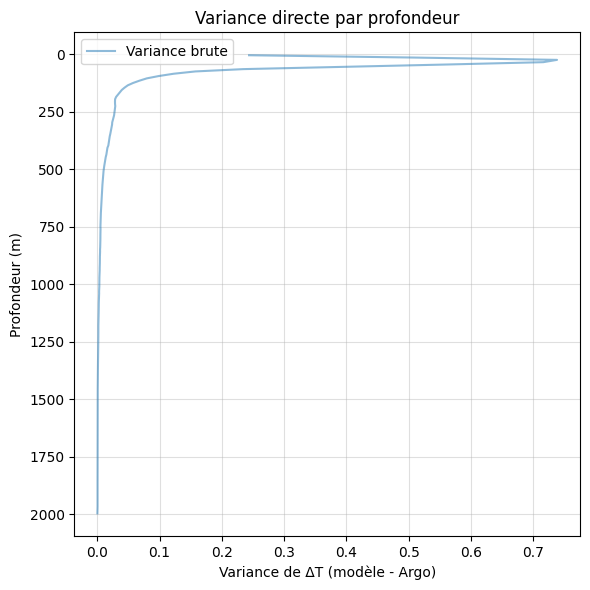

In [38]:
# 1) Extraction brutale des données
all_diff = np.concatenate([r["diff"] for r in results_copernicus])
all_pres = np.concatenate([r["pres"] for r in results_copernicus])

bins = np.linspace(0, 2000, 200)
indices = np.digitize(all_pres, bins)

# 3) Variance directe
var_profile_direct = []
depth_centers_direct = 0.5 * (bins[:-1] + bins[1:])

for i in range(1, len(bins)):
    diffs = all_diff[indices == i]
    if diffs.size > 3:
        var_profile_direct.append(np.nanvar(diffs))
    else:
        var_profile_direct.append(np.nan)

var_profile_direct = np.array(var_profile_direct)
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d  # option pour lisser

# --- Données déjà calculées ---
var_profile_direct = np.array(var_profile_direct)
depth_centers_direct = np.array(depth_centers_direct)

# --- Plot ---
plt.figure(figsize=(6, 6))
plt.plot(var_profile_direct, depth_centers_direct, label="Variance brute", alpha=0.5)

plt.gca().invert_yaxis()  # profondeur vers le bas
plt.xlabel("Variance de ΔT (modèle - Argo)")
plt.ylabel("Profondeur (m)")
plt.title("Variance directe par profondeur")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
import numba
import numpy as np
import xarray as xr

def interp_var_at_depth(var_depth, var_values, tag_depth):
    from scipy.interpolate import interp1d
    interp = interp1d(
        var_depth,           # profondeur bin (centres)
        var_values,          # variance associée
        bounds_error=False,
        fill_value=(var_values[0], var_values[-1]),
        axis=-1,
    )
    return interp(tag_depth)   # profondeur cible (profil Argo typiquement)


In [40]:
# Convertir en DataArray (plus pratique)
depth_da = xr.DataArray(depth_centers_direct, dims=["depth_bin"])
var_da   = xr.DataArray(var_profile_direct, dims=["depth_bin"])

# Profondeurs Argo / modèle (au format xarray)
tag_pressure = reshaped_tag["pressure"]  # (obs,)

# interpolation VARIANCE DIRECTE à ces profondeurs
var_direct_interp = xr.apply_ufunc(
    interp_var_at_depth,
    depth_da,         # 1D
    var_da,           # 1D
    tag_pressure,     # (obs,) ou (profil, obs)
    input_core_dims=[["depth_bin"], ["depth_bin"], ["obs"]],
    output_core_dims=[["obs"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[var_da.dtype],
)
var_direct_interp

<xarray.DataArray (time: 653, obs: 17280)> Size: 90MB
dask.array<transpose, shape=(653, 17280), dtype=float64, chunksize=(1, 17280), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 5kB 2023-11-04 2023-11-05 ... 2025-08-17
  * obs      (obs) int64 138kB 0 1 2 3 4 5 ... 17275 17276 17277 17278 17279

We define  $f(x, t )$ as difference difference between model simulated temperature, and observed temperature by fish. 

General definition of Probability Destribution Function (PDF) for difference observed in a location $x$, $F_{\mathrm{PDF}}(x)$ can be expressed as following. 



$F_{\mathrm{PDF}}(x)=\frac{1}{\sqrt{2\pi}\,\sigma}
\exp\!\left(-\frac{f(x)^{2}}{2\,\sigma^{2}}\right)$


Here, as our observation is also a function of each observation_time $t$,  thus we can expand it as follows.

$F_{\mathrm{PDF}}(x,t)=\frac{1}{\sqrt{2\pi}\,\sigma(t)}
\exp\!\left(-\frac{f(x,t)^{2}}{2\,\sigma(t)^{2}}\right)$

Here $\sigma(t)$, as it varies with each observation, we express it as function of time.  


Here’s the natural-log (ln) form:

${
\log F_{\mathrm{PDF}}(x,t)
= -\tfrac{1}{2}\,\log(2\pi)\;-\;\log \sigma(t)\;-\;\frac{f(x,t)^2}{2\,\sigma(t)^2}
}$


The cummurative probability of  time $T$, when $t\in T $, $\tilde F_{\mathrm{PDF}}(x,T)$ can be expressed as following

$\boxed{
\tilde F_{\mathrm{PDF}}(x,T)
=\prod_{t\in T} F_{\mathrm{PDF}}(x,t)
=\exp\!\Bigg(\sum_{t\in T}\underbrace{
-\tfrac12\log(2\pi)-\log\sigma(t)-\frac{f(x,t)^2}{2\,\sigma(t)^2}
}
\Bigg)
}
$

Here, in our calculation, we compute $X = \sigma(t)^2$

Thus above equation can be re written as following


$=\exp\!\Bigg(\sum_{t\in T}\underbrace{
-\tfrac12\log(2\pi)-\log X^{1/2} -\frac{f(x,t)^2}{2\,X}
}
)
$


$=\exp\!\Bigg(\sum_{t\in T}\underbrace{
-\tfrac12\log(2\pi)-1/2\log X -\frac{f(x,t)^2}{2\,X}
}
)
$




$$
= \exp\Bigg(
  -\frac12 \sum_{t\in T}
  \left(
    \log(2\pi) + \log X - \frac{f(x,t)^2}{X}
  \right)
\Bigg)
$$


In [41]:
from numba import njit
import numpy as np

from numba import njit

@njit
def fast_likelihood(tag_temp, model_temp, var_at_depth):
    diff_temp = (tag_temp - model_temp)**2 / (var_at_depth + 0.01)
    log_prob  = -0.5 * (np.log(2*np.pi) + np.log(var_at_depth + 0.01) + diff_temp)
    return np.exp(np.nanmean(log_prob))


def likelihood_fast(model_temp, model_depth, tag_temp, tag_depth, var_at_depth):
    from scipy.interpolate import interp1d

    mask = ~np.isnan(tag_depth)
    tag_depth_ = tag_depth[mask]
    tag_temp_ = tag_temp[mask]
    var_at_depth_ = var_at_depth[mask]

    mask_model = np.isfinite(model_depth) & np.isfinite(model_temp)
    model_depth_ = model_depth[mask_model]
    model_temp_  = model_temp[mask_model]

    if model_depth_.size == 0:
        return np.nan

    model_temp_at_depth = interp1d(
        model_depth_, model_temp_,
        bounds_error=False,
        fill_value=(model_temp_[0], model_temp_[-1])
    )(tag_depth_)

    return fast_likelihood(tag_temp_, model_temp_at_depth, var_at_depth_)


diff = xr.apply_ufunc(
    likelihood_fast,
    reference_model["TEMP"],
    reference_model["dynamic_depth"],
    reshaped_tag["temperature"],
    reshaped_tag["pressure"],
    var_direct_interp,
    input_core_dims=[["depth"], ["depth"], ["obs"], ["obs"], ["obs"]],
    output_core_dims=[[]],
    dask="parallelized",
    vectorize=True,
    output_dtypes=[reference_model["TEMP"].dtype],
)
diff = diff.to_dataset(name="diff").assign(
    {
        "H0": reference_model["H0"],
        "XE": reference_model["XE"],
        "ocean_mask": reference_model["H0"].notnull(),
    })
diff = diff.compute()

/home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 174.96 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2026-04-13 19:49:10,652 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('vectorize_likelihood_fast-vectorize_likelihood_fast_0-transpose-bd9ffff7e536832d6264ff843a733f69', 593, 0, 1))" coro=<Worker.execute() done, defined at /home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/distributed/worker_state_machine.py:3607>> ended with CancelledError
2026-04-13 19:49:10,653 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('vectorize_likel

KeyboardInterrupt: 

In [ ]:
diff

_We can detect abnormal data by looking at the number of non null values for each time step._

In [ ]:
diff["diff"].count(["lat", "lon"]).plot()
diff

In [ ]:
diff.to_zarr(
    f"{target_root}/diff.zarr",
    mode="w",
    storage_options=storage_options,
    zarr_version=2,
)

del diff

## 3. HEALPix regridding

In this step, we regrid the data from above to HEALPix coordinates. 

This is a complex process, composed of several steps such as defining the HEALPix grid, creating the target grid and computing interpolation weights

Fortunately though, `pangeo-fish` embarks high-level functions to do the work for us!

In [21]:
from pangeo_fish.helpers import open_diff_dataset, regrid_dataset

# Open the previous dataset (only necessary if you resume the notebook from here)
diff = open_diff_dataset(target_root=target_root, storage_options=storage_options)
diff

/home/ecap/CLAUDE/pangeo-fish-public/notebooks/../pangeo_fish/helpers.py:548: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  .pipe(lambda ds: ds.merge(ds[["latitude", "longitude"]].compute()))
/home/ecap/CLAUDE/pangeo-fish-public/notebooks/../pangeo_fish/helpers.py:548: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  .pipe(lambda ds: ds.

<xarray.Dataset> Size: 3GB
Dimensions:     (yi: 481, xi: 913, time: 454)
Coordinates:
    latitude    (yi, xi) float32 2MB 20.0 20.0 20.0 20.0 ... 60.0 60.0 60.0 60.0
    longitude   (yi, xi) float32 2MB -50.0 -49.92 -49.83 ... 25.83 25.92 26.0
  * time        (time) datetime64[ns] 4kB 2022-08-09 2022-08-10 ... 2023-11-05
Dimensions without coordinates: yi, xi
Data variables:
    H0          (yi, xi) float32 2MB dask.array<chunksize=(481, 913), meta=np.ndarray>
    XE          (time, yi, xi) float64 2GB dask.array<chunksize=(8, 481, 913), meta=np.ndarray>
    diff        (time, yi, xi) float64 2GB dask.array<chunksize=(57, 61, 115), meta=np.ndarray>
    ocean_mask  (yi, xi) bool 439kB dask.array<chunksize=(241, 913), meta=np.ndarray>

In [22]:
reshaped = regrid_dataset(
    ds=diff.compute(),
    refinement_level=refinement_level,
    min_vertices=min_vertices,
    rot=rot,
    dims=dims,
)[0]
reshaped

/home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/xhealpixify/interpolation/mask.py:22: RuntimeWarning: invalid value encountered in divide
  return masked_weights / np.sum(masked_weights, axis=-1)[:, None]


<xarray.Dataset> Size: 313MB
Dimensions:     (cells: 42844, time: 454)
Coordinates:
    cell_ids    (cells) int64 343kB 10935 10939 10940 ... 327677 327678 327679
    latitude    (cells) float64 343kB 20.26 20.26 20.26 ... 41.41 41.41 41.61
    longitude   (cells) float64 343kB 24.26 23.55 23.91 ... 0.1758 -0.1758 0.0
  * time        (time) datetime64[ns] 4kB 2022-08-09 2022-08-10 ... 2023-11-05
    resolution  float64 8B 0.003997
Dimensions without coordinates: cells
Data variables:
    H0          (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    XE          (time, cells) float64 156MB dask.array<chunksize=(255, 42844), meta=np.ndarray>
    diff        (time, cells) float64 156MB dask.array<chunksize=(255, 42844), meta=np.ndarray>
    ocean_mask  (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
Attributes:
    grid_type:     healpix
    level:         8
    nside:         256
    lat:           0
    lon:           0
    rot_lat:       0
    rot_lon:       0
    comment:       pangeo-fish == 2026.3.0, healpix-convolution == 0.1.2, xar...
    min_vertices:  1

Let's plot the same chart as before to check that the HEALPix regridding hasn't changed the data

/home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 1.49 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


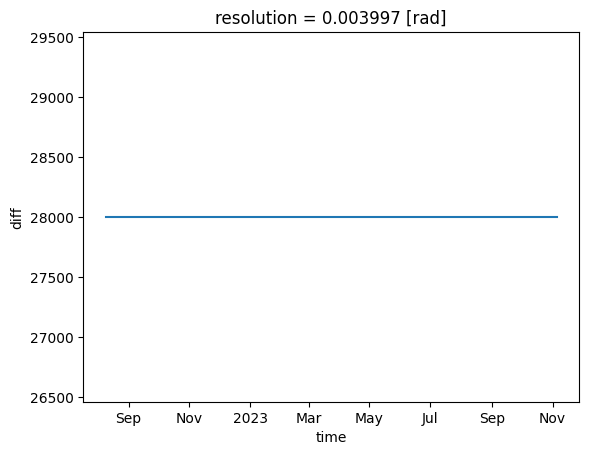

In [23]:
reshaped["diff"].count(dims).plot()

In [24]:
reshaped["diff"].dggs.decode(
    {"grid_name": "healpix", "level": 8, "indexing_scheme": "nested"}
).compute().dggs.explore()

MapWithControls(colorbar=Colorbar(colors=[[0.267004, 0.004874, 0.329415], [0.26851, 0.009605, 0.335427], [0.26…

In [25]:
reshaped["diff"] = (
    reshaped["diff"] / reshaped["diff"].sum(dim="cells", skipna=True).compute()
).compute()

/home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 1.49 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 1.49 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [26]:
reshaped["diff"].sum()

<xarray.DataArray 'diff' ()> Size: 8B
array(454.)
Coordinates:
    resolution  float64 8B 0.003997

In [27]:
target_root

's3://gfts-ifremer/tuna_mediterranean/run/capetienne/bbox/level10/global_copernicus/20P0204_larger_bbox1'

In [14]:
# Saves the result
reshaped.chunk(default_chunk_dims).to_zarr(
    f"{target_root}/diff-regridded.zarr",
    mode="w",
    consolidated=True,
    compute=True,
    storage_options=storage_options,
    zarr_version=2,
)
del reshaped

/tmp/ipykernel_5184/1492199169.py:2: FutureWarning: zarr_version is deprecated, use zarr_format
  reshaped.chunk(default_chunk_dims).to_zarr(
/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 1.64 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


## 4. Compute the emission probability distribution

In this step, we use the comparison result from the step above to construct the emission probability matrix.

This comparison is essentially he differences between the temperature measured by the tag and the reference sea temperature. 

The emission probability matrix represents the likelihood of observing a specific temperature difference given the model parameters and configurations.

In [10]:
from pangeo_fish.helpers import compute_emission_pdf

In [11]:
# Open the previous dataset (only necessary if you resume the notebook from here)
differences = xr.open_dataset(
    f"{target_root}/diff-regridded.zarr",
    engine="zarr",
    chunks={},
    storage_options=storage_options,
).pipe(lambda ds: ds.merge(ds[["latitude", "longitude"]].compute()))
# ... and compute the emission matrices

In [12]:
differences

<xarray.Dataset> Size: 313MB
Dimensions:     (cells: 42844, time: 454)
Coordinates:
    cell_ids    (cells) int64 343kB 10935 10939 10940 ... 327677 327678 327679
    latitude    (cells) float64 343kB 20.26 20.26 20.26 ... 41.41 41.41 41.61
    longitude   (cells) float64 343kB 24.26 23.55 23.91 ... 0.1758 -0.1758 0.0
    resolution  float64 8B 0.003997
  * time        (time) datetime64[ns] 4kB 2022-08-09 2022-08-10 ... 2023-11-05
Dimensions without coordinates: cells
Data variables:
    H0          (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    XE          (time, cells) float64 156MB dask.array<chunksize=(1, 42844), meta=np.ndarray>
    diff        (time, cells) float64 156MB dask.array<chunksize=(1, 42844), meta=np.ndarray>
    ocean_mask  (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
Attributes:
    comment:       pangeo-fish == 2025.3.4.dev20+g2e5c86fff.d20251210, healpi...
    grid_type:     healpix
    lat:           0
    level:         8
    lon:           0
    min_vertices:  1
    nside:         256
    rot_lat:       0
    rot_lon:       0

### I just create and add init + raw 

In [13]:
tag["tagging_events"].ds

<xarray.DatasetView> Size: 64B
Dimensions:     (event_name: 2)
Coordinates:
  * event_name  (event_name) object 16B 'release' 'fish_death'
Data variables:
    time        (event_name) datetime64[ns] 16B 2022-08-09T16:00:00 2023-11-0...
    longitude   (event_name) float64 16B -2.994 -1.861
    latitude    (event_name) float64 16B 47.13 46.57

In [14]:
emission_pdf = compute_emission_pdf(
    diff_ds=differences,
    events_ds=tag["tagging_events"].ds,
    differences_std=differences_std,
    initial_std=initial_std,
    recapture_std=recapture_std,
    dims=dims,
    chunk_time=chunk_time,
)[0]
emission_pdf["pdf"] = differences["diff"]
emission_pdf

good init
0.001
good final
<xarray.Dataset> Size: 64B
Dimensions:     ()
Coordinates:
    event_name  <U10 40B 'fish_death'
Data variables:
    time        datetime64[ns] 8B 2023-11-05T19:01:04
    longitude   float64 8B -1.861
    latitude    float64 8B 46.57
0.001


<xarray.Dataset> Size: 158MB
Dimensions:     (cells: 42844, time: 454)
Coordinates:
  * cell_ids    (cells) int64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    latitude    (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    longitude   (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    resolution  float64 8B 0.003997
  * time        (time) datetime64[ns] 4kB 2022-08-09 2022-08-10 ... 2023-11-05
Dimensions without coordinates: cells
Data variables:
    pdf         (time, cells) float64 156MB dask.array<chunksize=(1, 42844), meta=np.ndarray>
    initial     (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    final       (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    mask        (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
Indexes:
    cell_ids  HealpixIndex(level=8, indexing_scheme=nested)
Attributes:
    comment:          pangeo-fish == 2025.3.4.dev20+g2e5c86fff.d20251210, hea...
    grid_type:        healpix
    lat:              0
    level:            8
    lon:              0
    min_vertices:     1
    nside:            256
    rot_lat:          0
    rot_lon:          0
    differences_std:  1.0
    recapture_std:    0.001
    initial_std:      0.001

In [15]:
emission_pdf = emission_pdf.dggs.decode(
    {"grid_name": "healpix", "level": 8, "indexing_scheme": "nested"}
)
emission_pdf.final.compute().where(lambda x: x > 0).dggs.explore()

Map(custom_attribution='', layers=(SolidPolygonLayer(filled=True, get_fill_color=arro3.core.ChunkedArray<Fixed…

In [16]:
emission_pdf.pdf.compute().sum()

<xarray.DataArray 'pdf' ()> Size: 8B
array(454.)
Coordinates:
    resolution  float64 8B 0.003997

Whatever the temporal distribution looks like, they must **never** (i.e, at _any time step_) sum to 0.

How could we check that visually? You'd have guessed it by now: similarly as before!

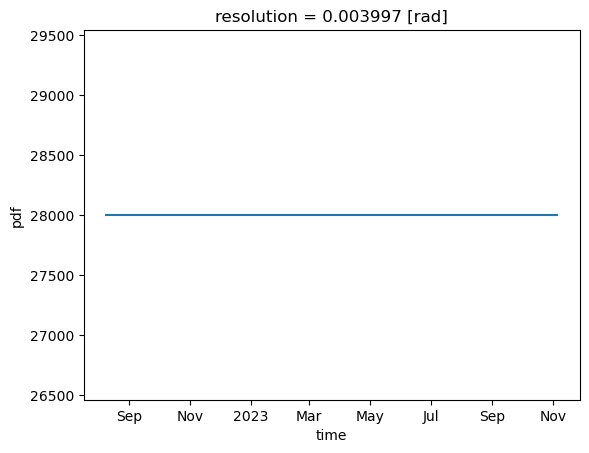

In [17]:
emission_pdf = emission_pdf.chunk(default_chunk_dims).persist()
emission_pdf["pdf"].count(dims).plot()

In [18]:
# Save the dataset
emission_pdf.compute().to_zarr(
    f"{target_root}/emission.zarr",
    mode="w",
    consolidated=True,
    storage_options=storage_options,
    zarr_version=2,
)

/tmp/ipykernel_5824/3772922378.py:2: FutureWarning: zarr_version is deprecated, use zarr_format
  emission_pdf.compute().to_zarr(


## 5. Bathymetry PDF

Compute a per-timestep depth likelihood from the GEBCO bathymetric histogram and the tag pressure record, then merge it with the temperature-difference PDF.

### Compute or load from cache

In [ ]:
# ── Load emission_pdf if not already in scope (allows running ch5 after ch1 only) ──
import xarray as xr
try:
    emission_pdf
except NameError:
    emission_pdf = xr.open_dataset(
        f"{target_root}/emission.zarr",
        engine="zarr",
        chunks=default_chunk_dims,
        inline_array=True,
        storage_options=storage_options,
    )
    print("Loaded emission_pdf from zarr.")

import fsspec
import healpy as hp
import numpy as np
from pangeo_fish.bathy import batch_compute_pdf_bathy, compute_healpix_histogram_region_bin_size
from pangeo_fish.cf import bounds_to_bins
from pangeo_fish.tags import reshape_by_bins

zarr_path = f"{target_root}/bathy_pdf_{tag_name}.zarr"
fs = fsspec.filesystem("s3", **storage_options)
already_computed = fs.exists(zarr_path)
print("Bathy PDF already on S3 — loading." if already_computed else "Not found — computing.")

In [ ]:
if not already_computed:
    # ── GEBCO bathymetry ───────────────────────────────────────
    full_bathy = xr.open_dataset(
        "s3://gfts-reference-data/gebco_2024_new.zarr",
        engine="zarr",
        chunks={},
        storage_options=storage_options,
    ).rename({"lat": "latitude", "lon": "longitude"})

    subset_bathy = full_bathy.sel(
        {dim: slice(bounds[0], bounds[1]) for dim, bounds in bbox.items()}
    )

    ds_histo = compute_healpix_histogram_region_bin_size(
        subset_bathy,
        nside=nside,
        max_depth_m=1000,
        depth_bin_size=16,
    )

    # Restrict histogram to cells shared with the emission PDF
    common = np.intersect1d(ds_histo.cell_ids.values, emission_pdf.cell_ids.values)
    mask = np.isin(ds_histo.cell_ids.values, common)
    ds_histo = ds_histo.isel(cells=np.where(mask)[0])

    # ── Reshape tag pressure to reference time grid ────────────
    reshaped_tag = reshape_by_bins(
        tag_log,
        dim="time",
        bins=(
            reference_model.cf.add_bounds(["time"], output_dim="bounds")
            .pipe(bounds_to_bins, bounds_dim="bounds")
            .get("time_bins")
        ),
        other_dim="obs",
    ).chunk({"time": chunk_time})

    # ── Compute and save ────────────────────────────────────────
    pdf_da = batch_compute_pdf_bathy(ds_histo, reshaped_tag, target_root, batch_size=1000)
    bathy_pdf_raw = pdf_da / pdf_da.sum(dim="cells", skipna=True)

    bathy_pdf_raw.compute().to_zarr(
        zarr_path, compute=True, mode="w",
        consolidated=True, zarr_version=2, storage_options=storage_options,
    )

In [ ]:
bathy_pdf = xr.open_dataset(
    zarr_path, engine="zarr", chunks={}, storage_options=storage_options,
)

bathy_pdf.dggs.decode(
    {"grid_name": "healpix", "level": 8, "indexing_scheme": "nested"}
).pdf_bathy.compute().where(lambda x: x > 0).dggs.explore()

### Normalise by ocean mask and merge

In [ ]:
from pangeo_fish.helpers import normalize_pdf_by_mask
import matplotlib.pyplot as plt

In [ ]:
# Apply ocean mask and uniform-prior fix to both PDFs
bathy_pdf["mask"] = emission_pdf["mask"]
bathy_pdf_corrected   = normalize_pdf_by_mask(bathy_pdf, pdf_var="pdf_bathy")
emission_pdf_corrected = normalize_pdf_by_mask(emission_pdf)

# Decode HEALPix for both
_hpx = {"grid_name": "healpix", "level": 8, "indexing_scheme": "nested"}
bathy_pdf_corrected    = bathy_pdf_corrected.dggs.decode(_hpx)
emission_pdf_corrected = emission_pdf_corrected.dggs.decode(_hpx)

In [ ]:
emission_with_bathy = emission_pdf_corrected.merge(bathy_pdf_corrected, compat="override")

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
emission_with_bathy["pdf"].count(dims).plot(ax=axes[0])
axes[0].set_title("Temperature diff — valid timesteps")
emission_with_bathy["pdf_bathy"].count(dims).plot(ax=axes[1])
axes[1].set_title("Bathymetry — valid timesteps")
plt.tight_layout()

### Combine, normalise, and save

In [ ]:
from pangeo_fish.helpers import normalize_pdf

combined_diff_bathy = normalize_pdf(
    ds=emission_with_bathy, chunks=default_chunk_dims, dims=dims,
)[0]

In [ ]:
combined_diff_bathy.dggs.decode(
    {"grid_name": "healpix", "level": 8, "indexing_scheme": "nested"}
).pdf.compute().dggs.explore()

In [ ]:
combined_diff_bathy.compute().to_zarr(
    f"{target_root}/emission_w_bathy_pdf_{tag_name}.zarr",
    compute=True, mode="w", consolidated=True, zarr_version=2,
    storage_options=storage_options,
)
del emission_pdf, combined_diff_bathy
print("Saved.")

## 6. Solar threshold PDF

Detect twilight events, self-calibrate the solar elevation threshold, and build per-night likelihood maps on a lat/lon grid.


In [ ]:
# ── HAS_LIGHT guard ───────────────────────────────────────────────────────
# If the tag has no usable raw light data, skip Ch6 (solar) and Ch7 (lunar).
if not HAS_LIGHT:
    print("HAS_LIGHT=False — solar and lunar PDFs are skipped.")
    print("pdf_light_healpix and pdf_moon_healpix set to None for Ch8.")
    pdf_light_healpix = None
    pdf_moon_healpix  = None

In [57]:
if HAS_LIGHT:
    import pandas as pd
    import numpy as np
    import ephem
    
    # ── Load raw DST data from the tag DataTree ────────────────────────────────
    # tag["/dst"].ds has a single time dimension (2.6 M rows at ~15-s resolution).
    df_raw = (
        tag["/dst"].ds[["light", "pressure", "temperature"]]
        .to_dataframe()
        .reset_index()
    )
    df_raw["time"] = pd.to_datetime(df_raw["time"], utc=True)
    df_raw = df_raw.sort_values("time").set_index("time")
    
    # ── Resample to 1-minute resolution ───────────────────────────────────────
    # light: max  — captures the peak at each threshold crossing
    # pressure, temperature: mean
    df = df_raw.resample("1min").agg(
        {"light": "max", "pressure": "mean", "temperature": "mean"}
    )
    df = df.dropna(subset=["light"]).reset_index()
    
    print(f"{len(df):,} records, {df['time'].min().date()} → {df['time'].max().date()}")
    print(f"Light:    {df['light'].min():.0f}–{df['light'].max():.0f} counts")
    print(f"Pressure: 0–{df['pressure'].max():.0f} dbar")
    

652,470 records, 2022-08-09 → 2023-11-06
Light:    20–219 counts
Pressure: 0–566 dbar


In [58]:
if HAS_LIGHT:
    # ── Tag event positions ──────────────────────────────────────────────────
    release = tag["tagging_events"].ds.sel(event_name="release")
    RELEASE_LON = float(release["longitude"].values)
    RELEASE_LAT = float(release["latitude"].values)
    
    # Recapture / death position — used for end-period calibration verification.
    # Set to None if not available.
    try:
        recap = tag["tagging_events"].ds.sel(event_name="fish_death")
        RECAP_LON = float(recap["longitude"].values)
        RECAP_LAT = float(recap["latitude"].values)
    except KeyError:
        RECAP_LON = RECAP_LAT = None
    
    print(f"Release  : {RELEASE_LON:.3f}°E, {RELEASE_LAT:.3f}°N")
    print(f"Recapture: {RECAP_LON}°E, {RECAP_LAT}°N" if RECAP_LON else "Recapture: not available")

Release  : -2.994°E, 47.129°N
Recapture: -1.8615°E, 46.5743°N


### Parameters

In [59]:
if HAS_LIGHT:
    # ── Solar pipeline parameters ──────────────────────────────────────────────
    THRESH_LIGHT_BASE     = 60      # baseline dynamic threshold (counts)
    THRESH_LIGHT_AMP      = 20      # moon-phase amplitude (counts)
    THRESH_DEG_INIT       = -8.0   # initial elevation threshold; will be self-calibrated
    SIGMA_TIMING_MIN      = 20      # timing uncertainty (minutes)
    MAX_DEPTH_DBAR        = 80      # quality filter: max depth in twilight window (dbar)
    MIN_LIGHT_RANGE       = 60      # quality filter: minimum Δlight (counts)
    GAUSSIAN_SMOOTH       = 0.5     # spatial smoothing sigma (pixels)
    N_CALIB_NIGHTS        = 10      # nights used for start-period self-calibration
    N_CALIB_NIGHTS_END    = 10      # nights used for end-period verification (recapture)
    
    # Fixed threshold option: if True, all detections use max(dyn_thresh) = base+amp
    # instead of the per-row phase-dependent value.  More conservative;
    # avoids misclassifying bright-moon nights as day.
    USE_FIXED_THRESHOLD   = True
    
    # ── Solar grid: bbox + 1° margin ─────────────────────────────────────────
    LONS = np.arange(bbox["longitude"][0] - 1, bbox["longitude"][1] + 2, 1.0)
    LATS = np.arange(bbox["latitude"][0]  - 1, bbox["latitude"][1]  + 2, 1.0)

In [60]:
if HAS_LIGHT:
    from pangeo_fish.light import dynamic_threshold
    
    print("Computing lunar phases…")
    df["time_h"] = df["time"].dt.round("h")
    times_h = df["time_h"].unique()
    
    moon_phases = []
    for t in times_h:
        m = ephem.Moon(pd.Timestamp(t).strftime("%Y/%m/%d %H:%M:%S"))
        moon_phases.append({"time_h": t, "moon_phase": float(m.phase)})
    
    moon_df = pd.DataFrame(moon_phases).set_index("time_h")
    df = df.merge(moon_df, left_on="time_h", right_index=True, how="left")
    df["dyn_thresh"] = dynamic_threshold(
        df["moon_phase"], base=THRESH_LIGHT_BASE, amp=THRESH_LIGHT_AMP
    )
    print(f"Dynamic threshold range: {df['dyn_thresh'].min():.1f}–{df['dyn_thresh'].max():.1f}")
    

Computing lunar phases…
Dynamic threshold range: 60.0–80.0


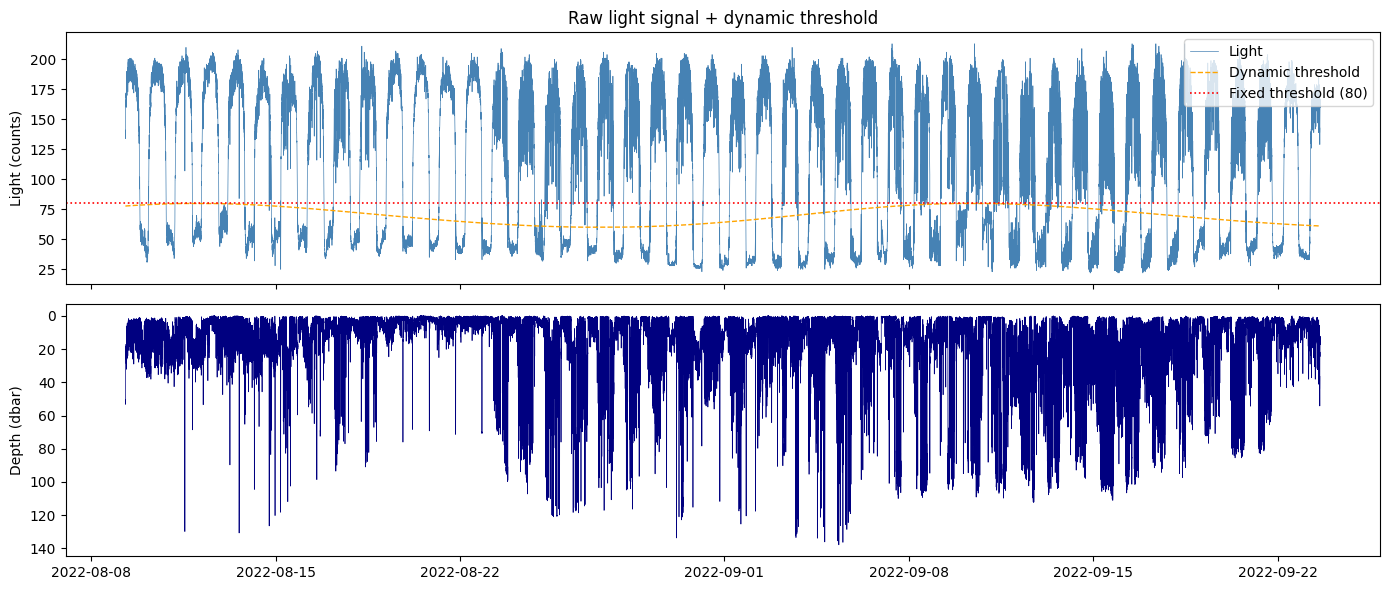

In [61]:
if HAS_LIGHT:
    import matplotlib.pyplot as plt
    
    early = df[df["time"] < df["time"].iloc[len(df) // 10]].copy()
    fixed_thresh = df["dyn_thresh"].max()
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    
    ax = axes[0]
    ax.plot(early["time"], early["light"], lw=0.5, color="steelblue", label="Light")
    ax.plot(early["time"], early["dyn_thresh"], lw=1.0, color="orange",
            linestyle="--", label="Dynamic threshold")
    if USE_FIXED_THRESHOLD:
        ax.axhline(fixed_thresh, lw=1.2, color="red",
                   linestyle=":", label=f"Fixed threshold ({fixed_thresh:.0f})")
    ax.set_ylabel("Light (counts)")
    ax.legend(loc="upper right")
    ax.set_title("Raw light signal + dynamic threshold")
    
    ax = axes[1]
    ax.plot(early["time"], early["pressure"], lw=0.5, color="navy")
    ax.set_ylabel("Depth (dbar)")
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

### Detection and calibration

In [62]:
if HAS_LIGHT:
    from pangeo_fish.light import detect_twilight_events
    
    pairs = detect_twilight_events(
        df,
        release_lon=RELEASE_LON,
        release_lat=RELEASE_LAT,
        window_h=2.5,
        use_fixed_threshold=USE_FIXED_THRESHOLD,
    )
    print(f"Paired nights: {len(pairs)}")
    if USE_FIXED_THRESHOLD:
        print(f"Fixed threshold: {df['dyn_thresh'].max():.1f} counts")

Paired nights: 441
Fixed threshold: 80.0 counts


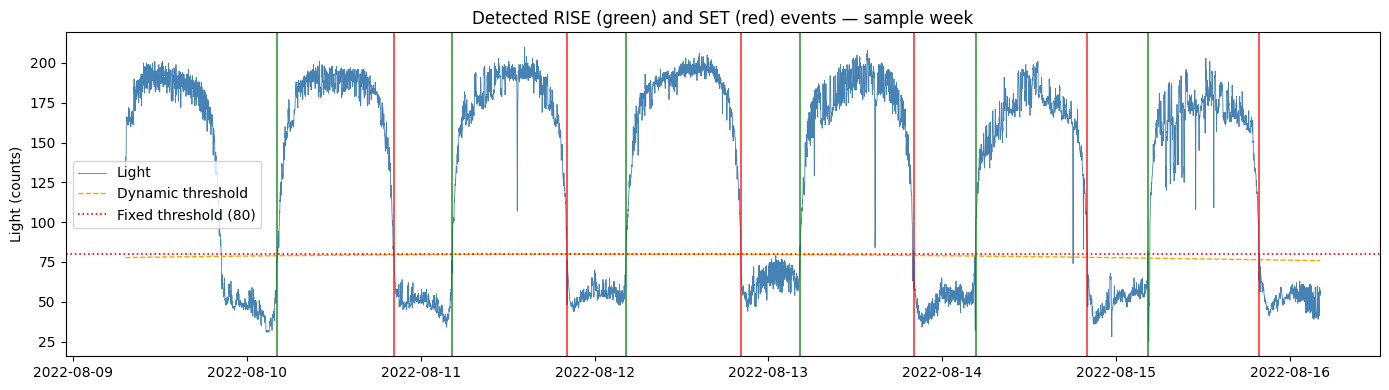

In [63]:
if HAS_LIGHT:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    
    t_start = pairs[0][0] - pd.Timedelta(days=1)
    t_end   = t_start + pd.Timedelta(days=7)
    sample  = df[(df["time"] >= t_start) & (df["time"] <= t_end)]
    fixed_thresh = df["dyn_thresh"].max()
    
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(sample["time"], sample["light"], lw=0.6, color="steelblue", label="Light")
    ax.plot(sample["time"], sample["dyn_thresh"], lw=1.0, color="orange",
            linestyle="--", label="Dynamic threshold")
    if USE_FIXED_THRESHOLD:
        ax.axhline(fixed_thresh, lw=1.2, color="red",
                   linestyle=":", label=f"Fixed threshold ({fixed_thresh:.0f})")
    
    for t_rise, t_set in pairs:
        if t_start <= t_rise <= t_end:
            ax.axvline(t_rise, color="green", lw=1.2, alpha=0.8)
        if t_start <= t_set <= t_end:
            ax.axvline(t_set, color="red", lw=1.2, alpha=0.8)
    
    ax.set_ylabel("Light (counts)")
    ax.set_title("Detected RISE (green) and SET (red) events — sample week")
    ax.legend()
    plt.tight_layout()
    plt.show()

Self-calibrated longitude : -3.56°E  (release: -2.99°E)
Threshold (start 10 nights) : -7.05°  
Threshold (end 10 nights at recapture): -7.74°  Δ = -0.69° → ✅ consistent


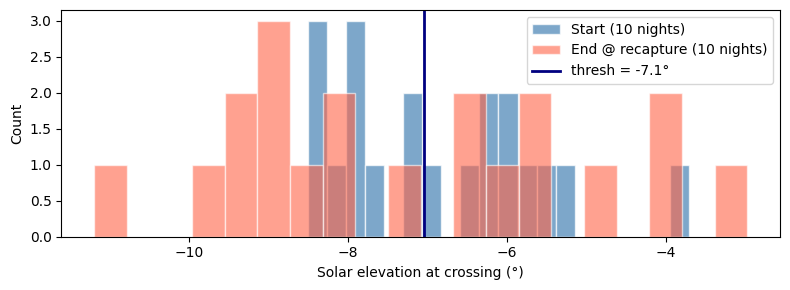

In [64]:
if HAS_LIGHT:
    from pangeo_fish.light import self_calibrate_solar_threshold
    
    calib = self_calibrate_solar_threshold(
        pairs, df,
        n_nights=N_CALIB_NIGHTS,
        release_lon=RELEASE_LON,
        release_lat=RELEASE_LAT,
        recapture_lon=RECAP_LON,
        recapture_lat=RECAP_LAT,
        n_nights_end=N_CALIB_NIGHTS_END,
    )
    THRESH_DEG = calib.thresh_deg
    
    print(f"Self-calibrated longitude : {calib.lon_self:.2f}°E  (release: {RELEASE_LON:.2f}°E)")
    print(f"Threshold (start {N_CALIB_NIGHTS} nights) : {THRESH_DEG:.2f}°  ")
    if calib.thresh_deg_end is not None:
        ok = abs(calib.delta_deg) < 2.0
        print(f"Threshold (end {N_CALIB_NIGHTS_END} nights at recapture): {calib.thresh_deg_end:.2f}°  "
              f"Δ = {calib.delta_deg:+.2f}° → {'✅ consistent' if ok else '⚠️  drift detected'}")
    
    # Elevation distribution
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(calib.elevations, bins=20, color="steelblue", edgecolor="white",
            alpha=0.7, label=f"Start ({N_CALIB_NIGHTS} nights)")
    if calib.elevations_end is not None:
        ax.hist(calib.elevations_end, bins=20, color="tomato", edgecolor="white",
                alpha=0.6, label=f"End @ recapture ({N_CALIB_NIGHTS_END} nights)")
    ax.axvline(THRESH_DEG, color="navy", lw=2, label=f"thresh = {THRESH_DEG:.1f}°")
    ax.set_xlabel("Solar elevation at crossing (°)")
    ax.set_ylabel("Count")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [65]:
if HAS_LIGHT:
    from pangeo_fish.light import compute_quality_flags
    
    qdf = compute_quality_flags(df, pairs, max_depth=MAX_DEPTH_DBAR)
    
    n_good    = (qdf["flag"] == "good").sum()
    n_partial = (qdf["flag"] == "partial").sum()
    n_bad     = (qdf["flag"] == "bad").sum()
    n_total   = len(qdf)
    print(f"Quality: {n_good} good, {n_partial} partial, {n_bad} bad / {n_total} nights")

Quality: 264 good, 89 partial, 88 bad / 441 nights


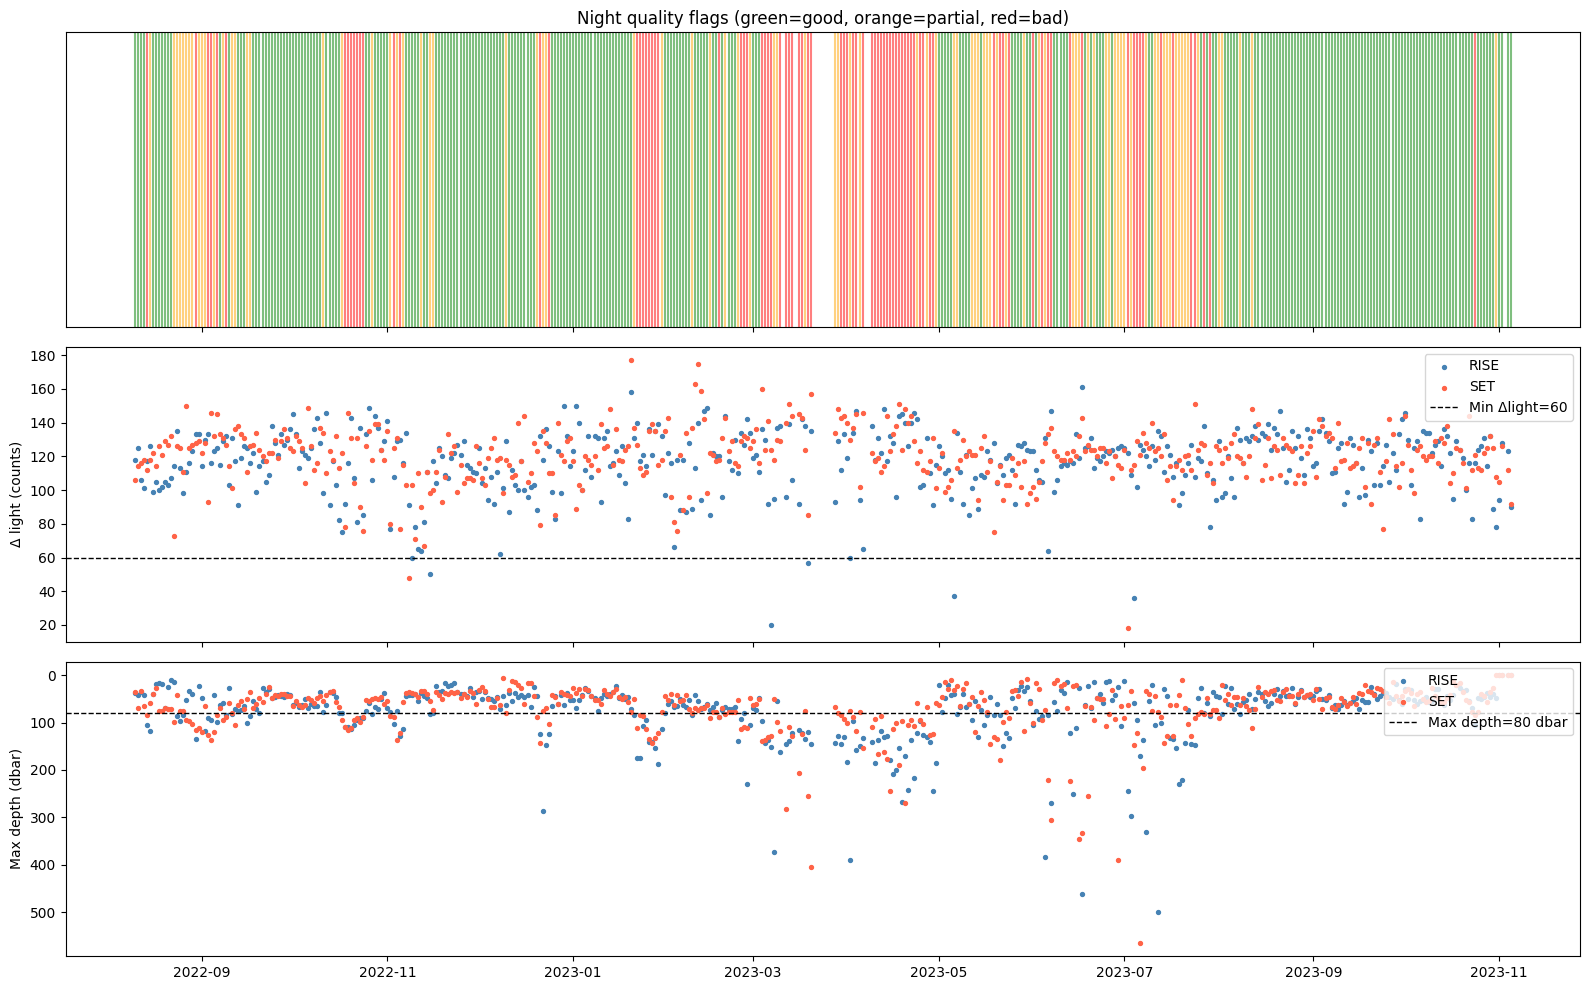

In [66]:
if HAS_LIGHT:
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    
    COLOR_MAP = {"good": "green", "partial": "orange", "bad": "red"}
    
    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
    
    # Panel 1: quality flags timeline
    ax = axes[0]
    for _, row in qdf.iterrows():
        ax.axvline(row["date"], color=COLOR_MAP[row["flag"]], alpha=0.5, lw=1.5)
    ax.set_yticks([])
    ax.set_title("Night quality flags (green=good, orange=partial, red=bad)")
    
    # Panel 2: Δlight per event
    ax = axes[1]
    ax.scatter(qdf["date"], qdf["dl_rise"], s=8, color="steelblue", label="RISE")
    ax.scatter(qdf["date"], qdf["dl_set"], s=8, color="tomato", label="SET")
    ax.axhline(MIN_LIGHT_RANGE, lw=1, ls="--", color="black", label=f"Min Δlight={MIN_LIGHT_RANGE}")
    ax.set_ylabel("Δ light (counts)")
    ax.legend(loc="upper right")
    
    # Panel 3: max depth per event
    ax = axes[2]
    ax.scatter(qdf["date"], qdf["dp_rise"], s=8, color="steelblue", label="RISE")
    ax.scatter(qdf["date"], qdf["dp_set"], s=8, color="tomato", label="SET")
    ax.axhline(MAX_DEPTH_DBAR, lw=1, ls="--", color="black", label=f"Max depth={MAX_DEPTH_DBAR} dbar")
    ax.set_ylabel("Max depth (dbar)")
    ax.invert_yaxis()
    ax.legend(loc="upper right")
    
    plt.tight_layout()
    plt.show()
    

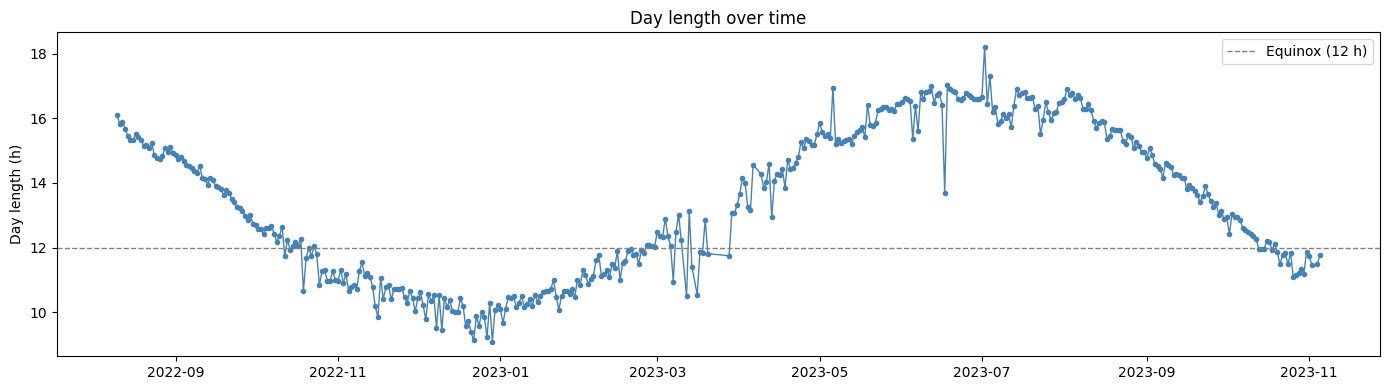

In [67]:
if HAS_LIGHT:
    from pangeo_fish.light.quality import _tz
    
    day_lengths = [
        (_tz(t_set) - _tz(t_rise)).total_seconds() / 3600
        for t_rise, t_set in pairs
    ]
    dates = [pd.Timestamp(t_rise.date()) for t_rise, t_set in pairs]
    
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(dates, day_lengths, "o-", ms=3, lw=1, color="steelblue")
    ax.axhline(12, ls="--", color="gray", lw=1, label="Equinox (12 h)")
    ax.set_ylabel("Day length (h)")
    ax.set_title("Day length over time")
    ax.legend()
    plt.tight_layout()
    plt.show()
    

### Solar likelihood maps

In [ ]:
if HAS_LIGHT:
    from pangeo_fish.light import compute_solar_likelihood
    
    pdf_light_latlon = compute_solar_likelihood(
        pairs,
        qdf,
        lons=LONS,
        lats=LATS,
        thresh_deg=THRESH_DEG,
        sigma_timing=SIGMA_TIMING_MIN,
        smooth_sigma=GAUSSIAN_SMOOTH,
    )
    print(pdf_light_latlon)

Solar likelihood:   0%|          | 0/441 [00:00<?, ?night/s]

In [ ]:
if HAS_LIGHT:
    import ipywidgets as widgets
    from IPython.display import display
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    
    FLAG_COLORS = {"good": "green", "partial": "orange", "bad": "red"}
    
    def show_night(night_idx):
        flag = qdf.iloc[night_idx]["flag"]
        date = qdf.iloc[night_idx]["date"]
        lh = pdf_light_latlon.isel(time=night_idx).values
    
        fig = plt.figure(figsize=(10, 5))
        ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
        im = ax.pcolormesh(
            LONS, LATS, lh,
            cmap="inferno", transform=ccrs.PlateCarree(), vmin=0, vmax=1,
        )
        ax.add_feature(cfeature.COASTLINE, lw=0.5)
        ax.add_feature(cfeature.BORDERS, lw=0.3)
        ax.set_title(
            f"Night {night_idx} — {date.date()} — flag: {flag}",
            color=FLAG_COLORS.get(flag, "black"), fontweight="bold",
        )
        plt.colorbar(im, ax=ax, shrink=0.8, label="Likelihood")
        plt.tight_layout()
        plt.show()
    
    slider = widgets.IntSlider(min=0, max=len(pairs)-1, step=1, description="Night:")
    widgets.interactive(show_night, night_idx=slider)
    

In [55]:
if HAS_LIGHT:
    import xarray as xr
    import numpy as np
    from xhealpixify import HealpyRegridder, HealpyGridInfo
    from pangeo_fish.grid import center_longitude
    
    # Build xr.Dataset with lat2d/lon2d coordinates required by HealpyRegridder
    ds_light_latlon = pdf_light_latlon.to_dataset(name="pdf_light")
    
    lon2d, lat2d = np.meshgrid(LONS, LATS)
    ds_light_latlon = ds_light_latlon.assign_coords(
        lat2d=(("latitude", "longitude"), lat2d),
        lon2d=(("latitude", "longitude"), lon2d),
    )
    
    
    # Build HEALPix target grid at the same level as the emission PDF
    grid_info = HealpyGridInfo(level=refinement_level)
    target_grid = grid_info.target_grid(ds_light_latlon).pipe(center_longitude, 0)
    
    regridder_light = HealpyRegridder(
        ds_light_latlon[["longitude", "latitude"]],
        target_grid,
        method="bilinear",
        interpolation_kwargs={"min_vertices": 1},
    )
    pdf_light_healpix = regridder_light.regrid_ds(ds_light_latlon).compute()
    
    print("HEALPix pdf_light:")
    print(pdf_light_healpix)
    
    # Save to zarr so ch8 can reload without re-running ch6
    pdf_light_healpix.to_zarr(
        f"{target_root}/pdf_light_healpix_{tag_name}.zarr",
        mode="w", consolidated=True, zarr_version=2,
        storage_options=storage_options,
    )
    print("Saved pdf_light_healpix.")

/home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 17.26 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


HEALPix pdf_light:
<xarray.Dataset> Size: 166MB
Dimensions:     (cells: 46028, time: 449)
Coordinates:
    cell_ids    (cells) uint64 368kB 10815 10831 10851 ... 327677 327678 327679
    latitude    (cells) float64 368kB 19.31 19.31 19.31 ... 41.41 41.41 41.61
    longitude   (cells) float64 368kB 25.31 26.72 26.02 ... 0.1758 -0.1758 0.0
  * time        (time) datetime64[ns] 4kB 2022-08-10 2022-08-11 ... 2023-11-05
    resolution  float64 8B 0.003997
Dimensions without coordinates: cells
Data variables:
    pdf_light   (time, cells) float64 165MB 3e-70 2.759e-74 ... 0.004304 0.00289
Attributes:
    grid_type:  healpix
    level:      8
    nside:      256
    lat:        0
    lon:        0
    rot_lat:    0
    rot_lon:    0


/tmp/ipykernel_10978/3677734676.py:32: FutureWarning: zarr_version is deprecated, use zarr_format
  pdf_light_healpix.to_zarr(


Saved pdf_light_healpix.


## 7. Lunar template-fit PDF

Find nights with a bright moon and shallow fish, correlate the observed light curve with the predicted moonlight illuminance at each pixel (Poon et al. 2024 MEE / Śmielak 2023), and convert to likelihood maps.


In [21]:
if HAS_LIGHT:
    # ── Lunar pipeline parameters ──────────────────────────────────────────────
    MIN_MOON_PHASE        = 60    # minimum moon illuminated fraction (%)
    MAX_MOON_DEPTH        = 15    # maximum fish depth for moonlight sensing (m)
    BIN_MIN               = 15    # time bin size (minutes)
    MIN_BINS              = 8     # minimum bins per night
    MIN_SAMPLES_PER_BIN   = 3     # minimum raw samples per bin
    SIGMA_R               = 0.25  # Spearman → likelihood sharpness (tuned value)
    
    # ── Lunar grid: bbox + 1° margin on each side ────────────────────────────
    # Wider than the solar grid is fine — the moon constrains longitude less tightly
    # and a larger domain costs little at 1° resolution.
    # The +1° margin ensures the intersection with the emission covers all cells.
    LONS_MOON = np.arange(bbox["longitude"][0] - 1, bbox["longitude"][1] + 2, 1.0)
    LATS_MOON = np.arange(bbox["latitude"][0]  - 1, bbox["latitude"][1]  + 2, 1.0)
    

In [22]:
if HAS_LIGHT:
    # ── Reload df if not in scope (allows running ch7 after ch1 without ch6) ──
    import pandas as pd
    try:
        df
    except NameError:
        df_raw = (
            tag["/dst"].ds[["light", "pressure", "temperature"]]
            .to_dataframe()
            .reset_index()
        )
        df_raw["time"] = pd.to_datetime(df_raw["time"], utc=True)
        df = (
            df_raw.sort_values("time").set_index("time")
            .resample("1min").agg({"light": "max", "pressure": "mean", "temperature": "mean"})
            .dropna(subset=["light"])
            .reset_index()
        )
        print("Reloaded df from tag.")
    
    from pangeo_fish.light import find_usable_moon_nights
    
    moon_nights = find_usable_moon_nights(
        df,
        min_phase=MIN_MOON_PHASE,
        max_depth_m=MAX_MOON_DEPTH,
        bin_min=BIN_MIN,
        min_bins=MIN_BINS,
        min_samples_per_bin=MIN_SAMPLES_PER_BIN,
    )
    
    print(f"Usable moon nights: {len(moon_nights)}")
    if moon_nights:
        print(f"Phase range: {min(n['phase'] for n in moon_nights):.0f}–"
              f"{max(n['phase'] for n in moon_nights):.0f}%")
        print(f"Mean bins/night: {np.mean([n['n_bins'] for n in moon_nights]):.0f}")
    
    if len(moon_nights) == 0:
        print("⚠️  No usable moon nights found — skipping lunar chapter.")
        print("    pdf_moon will be None; only pdf_light is used in the merge step.")
    

Usable moon nights: 191
Phase range: 60–100%
Mean bins/night: 37


In [23]:
if HAS_LIGHT:
    from pangeo_fish.light import compute_lunar_correlation_maps
    
    if moon_nights:
        print(f"Computing {len(moon_nights)} nights × "
              f"{len(LATS_MOON)*len(LONS_MOON)} pixels…")
        moon_nights = compute_lunar_correlation_maps(moon_nights, LONS_MOON, LATS_MOON)
        print("\n✔ All maps computed")
    

Computing 191 nights × 3397 pixels…
  [  1/191] 2022-08-09 ph= 87% r=1.000 c=(-5.3°, 40.9°) [6.6s]
  [ 11/191] 2022-09-05 ph= 65% r=0.988 c=(-10.3°, 34.8°) [6.9s]
  [ 21/191] 2022-09-15 ph= 77% r=0.968 c=(-13.3°, 39.3°) [5.1s]
  [ 31/191] 2022-10-12 ph= 95% r=0.793 c=(-13.3°, 40.4°) [9.1s]
  [ 41/191] 2022-11-08 ph=100% r=0.684 c=(+3.4°, 39.2°) [7.6s]
  [ 51/191] 2022-12-04 ph= 84% r=0.929 c=(-8.0°, 39.2°) [6.5s]
  [ 61/191] 2022-12-14 ph= 72% r=0.930 c=(-14.0°, 39.9°) [10.8s]
  [ 71/191] 2023-01-08 ph= 99% r=0.750 c=(+4.1°, 39.4°) [4.2s]
  [ 81/191] 2023-02-03 ph= 93% r=0.667 c=(-1.2°, 40.6°) [2.9s]
  [ 91/191] 2023-03-06 ph= 98% r=0.943 c=(-7.0°, 39.5°) [2.9s]
  [101/191] 2023-04-01 ph= 77% r=-0.232 c=(+nan°, nan°) [1.3s]
  [111/191] 2023-05-02 ph= 86% r=0.786 c=(-5.0°, 41.4°) [7.9s]
  [121/191] 2023-05-29 ph= 63% r=1.000 c=(+4.8°, 36.8°) [8.0s]
  [131/191] 2023-06-08 ph= 80% r=1.000 c=(-12.6°, 34.6°) [7.6s]


/home/ecap/CLAUDE/pangeo-fish-public/notebooks/../pangeo_fish/light/lunar.py:167: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(light_bin[valid], pred[valid])


  [141/191] 2023-07-06 ph= 90% r=0.995 c=(-11.9°, 36.0°) [7.6s]
  [151/191] 2023-08-02 ph=100% r=0.966 c=(-22.5°, 46.2°) [8.9s]
  [161/191] 2023-08-30 ph= 98% r=0.430 c=(+8.2°, 45.5°) [9.5s]
  [171/191] 2023-09-27 ph= 92% r=0.594 c=(+6.4°, 39.4°) [9.5s]
  [181/191] 2023-10-25 ph= 81% r=0.783 c=(-11.4°, 39.5°) [9.9s]
  [191/191] 2023-11-04 ph= 63% r=0.908 c=(-10.7°, 41.2°) [10.8s]

✔ All maps computed


In [24]:
if HAS_LIGHT:
    from pangeo_fish.light import correlation_to_likelihood
    
    if moon_nights:
        moon_nights = correlation_to_likelihood(moon_nights, sigma_r=SIGMA_R)
        n_valid = sum(1 for mn in moon_nights if mn.get("lh_map") is not None)
        print(f"Likelihood maps computed for {n_valid}/{len(moon_nights)} nights")
    

Likelihood maps computed for 191/191 nights


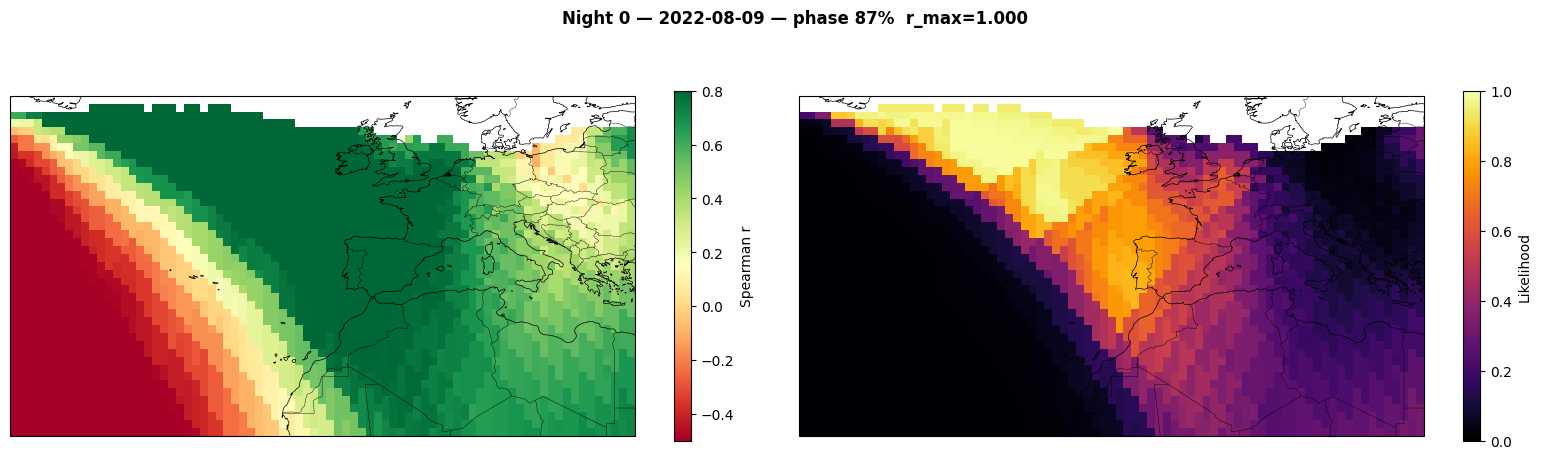

In [25]:
if HAS_LIGHT:
    import ipywidgets as widgets
    from IPython.display import display
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    
    def show_moon_night(night_idx):
        if not moon_nights:
            print("No usable moon nights.")
            return
        mn = moon_nights[night_idx]
        cm = mn.get("corr_map")
        lh = mn.get("lh_map")
        if cm is None:
            print("No map for this night.")
            return
    
        fig, axes = plt.subplots(1, 2, figsize=(16, 5),
                                  subplot_kw={"projection": ccrs.PlateCarree()})
        for ax, data, label, cmap, vmin, vmax in [
            (axes[0], cm, "Spearman r", "RdYlGn", -0.5, 0.8),
            (axes[1], lh, "Likelihood", "inferno", 0, 1),
        ]:
            if data is None:
                continue
            im = ax.pcolormesh(LONS_MOON, LATS_MOON, data,
                               cmap=cmap, transform=ccrs.PlateCarree(),
                               vmin=vmin, vmax=vmax)
            ax.add_feature(cfeature.COASTLINE, lw=0.5)
            ax.add_feature(cfeature.BORDERS, lw=0.3)
            plt.colorbar(im, ax=ax, shrink=0.8, label=label)
        fig.suptitle(f"Night {night_idx} — {mn['date'].date()} — "
                     f"phase {mn['phase']:.0f}%  r_max={mn.get('best_r', 0):.3f}",
                     fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.show()
    
    if moon_nights:
        slider_m = widgets.IntSlider(min=0, max=len(moon_nights)-1, step=1,
                                      description="Night:")
        widgets.interactive(show_moon_night, night_idx=slider_m)
    

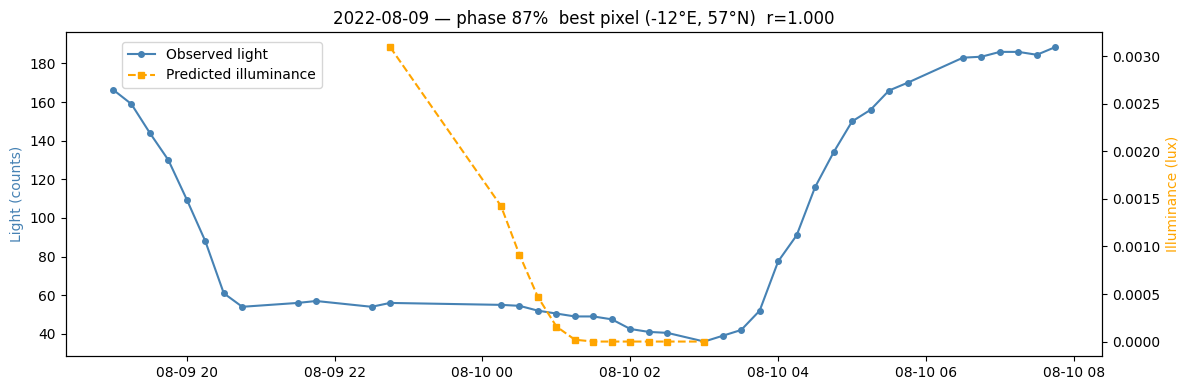

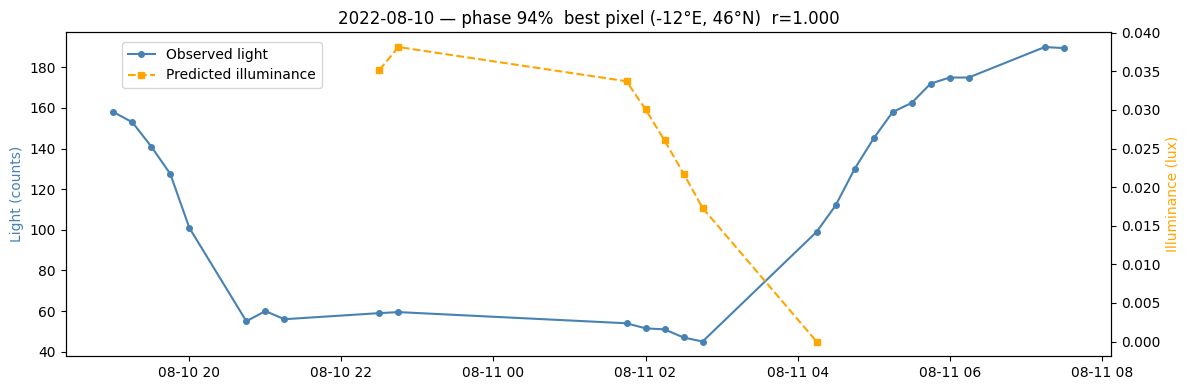

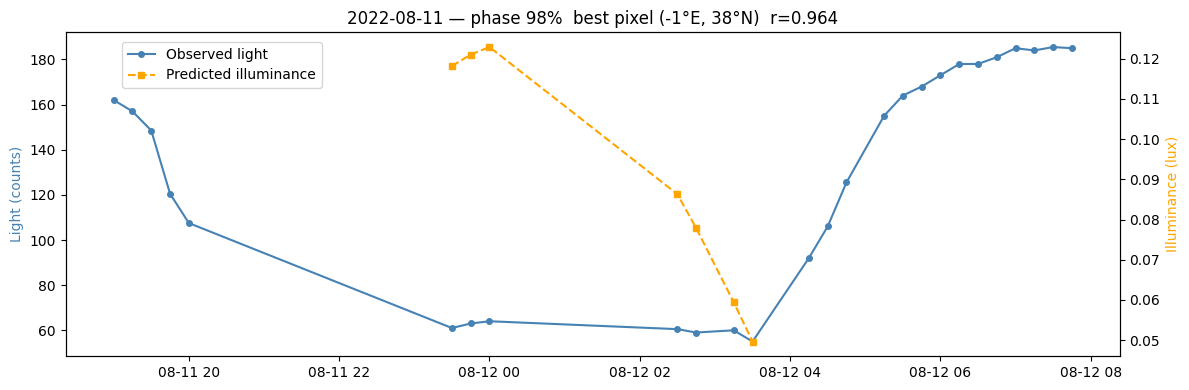

In [26]:
if HAS_LIGHT:
    import matplotlib.pyplot as plt
    from pangeo_fish.light.physics import predicted_moon_curve
    
    good_nights = [mn for mn in moon_nights
                   if mn.get("best_r", 0) > 0.5][:3] if moon_nights else []
    
    for mn in good_nights:
        pred = predicted_moon_curve(mn["times"], mn["best_lon"], mn["best_lat"])
    
        fig, ax1 = plt.subplots(figsize=(12, 4))
        ax2 = ax1.twinx()
    
        times_dt = [pd.Timestamp(t) for t in mn["times"]]
        ax1.plot(times_dt, mn["light"], "o-", ms=4, lw=1.5,
                 color="steelblue", label="Observed light")
        ax2.plot(times_dt, pred, "s--", ms=4, lw=1.5,
                 color="orange", label="Predicted illuminance")
    
        ax1.set_ylabel("Light (counts)", color="steelblue")
        ax2.set_ylabel("Illuminance (lux)", color="orange")
        ax1.set_title(f"{mn['date'].date()} — phase {mn['phase']:.0f}%  "
                      f"best pixel ({mn['best_lon']:.0f}°E, {mn['best_lat']:.0f}°N)  "
                      f"r={mn['best_r']:.3f}")
        fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
        plt.tight_layout()
        plt.show()
    

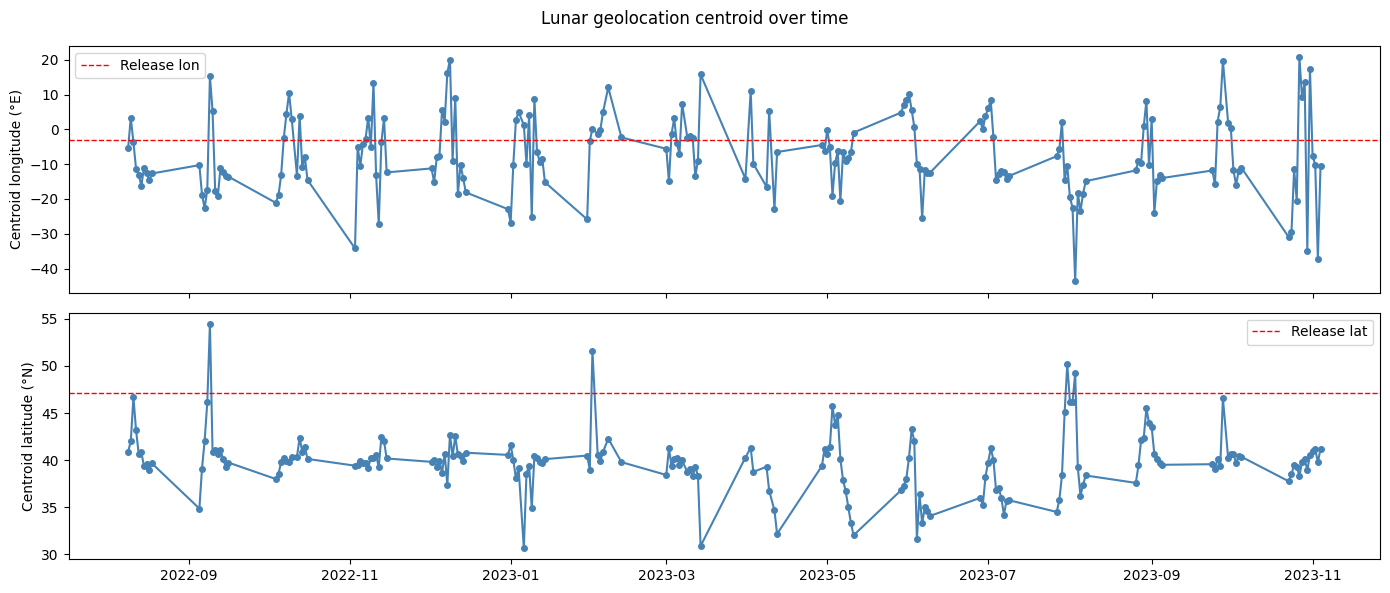

In [27]:
if HAS_LIGHT:
    import matplotlib.pyplot as plt
    
    if moon_nights:
        valid = [mn for mn in moon_nights if not np.isnan(mn.get("c_lon", np.nan))]
        dates   = [mn["date"].date() for mn in valid]
        c_lons  = [mn["c_lon"] for mn in valid]
        c_lats  = [mn["c_lat"] for mn in valid]
    
        fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
        axes[0].plot(dates, c_lons, "o-", ms=4, color="steelblue")
        axes[0].axhline(RELEASE_LON, ls="--", color="red", lw=1, label="Release lon")
        axes[0].set_ylabel("Centroid longitude (°E)")
        axes[0].legend()
    
        axes[1].plot(dates, c_lats, "o-", ms=4, color="steelblue")
        axes[1].axhline(RELEASE_LAT, ls="--", color="red", lw=1, label="Release lat")
        axes[1].set_ylabel("Centroid latitude (°N)")
        axes[1].legend()
    
        fig.suptitle("Lunar geolocation centroid over time", fontsize=12)
        plt.tight_layout()
        plt.show()
    

In [28]:
if HAS_LIGHT:
    from pangeo_fish.light import lunar_likelihood_to_dataarray
    
    if moon_nights:
        pdf_moon_latlon = lunar_likelihood_to_dataarray(moon_nights, LONS_MOON, LATS_MOON)
        print(pdf_moon_latlon)
    
        # Regrid to HEALPix
        ds_moon_latlon = pdf_moon_latlon.to_dataset(name="pdf_moon")
        lon2d_m, lat2d_m = np.meshgrid(LONS_MOON, LATS_MOON)
        ds_moon_latlon = ds_moon_latlon.assign_coords(
            lat2d=(("latitude", "longitude"), lat2d_m),
            lon2d=(("latitude", "longitude"), lon2d_m),
        )
        grid_info_m = HealpyGridInfo(level=refinement_level)
        target_grid_m = grid_info_m.target_grid(ds_moon_latlon).pipe(center_longitude, 0)
        regridder_moon = HealpyRegridder(
            ds_moon_latlon[["longitude", "latitude"]],
            target_grid_m,
            method="bilinear",
            interpolation_kwargs={"min_vertices": 1},
        )
        pdf_moon_healpix = regridder_moon.regrid_ds(ds_moon_latlon).compute()
        print("HEALPix pdf_moon:")
        print(pdf_moon_healpix)
    else:
        pdf_moon_healpix = None
        print("No moon nights — pdf_moon is None (will be skipped in merge step).")
    
    # Save to zarr so ch8 can reload without re-running ch7
    if moon_nights and pdf_moon_healpix is not None:
        pdf_moon_healpix.to_zarr(
            f"{target_root}/pdf_moon_healpix_{tag_name}.zarr",
            mode="w", consolidated=True, zarr_version=2,
            storage_options=storage_options,
        )
        print("Saved pdf_moon_healpix.")

<xarray.DataArray 'pdf_moon' (time: 191, latitude: 43, longitude: 79)> Size: 5MB
array([[[6.49215204e-04, 6.13262786e-04, 7.21952215e-04, ...,
         3.26601747e-01, 3.02130615e-01, 3.26820957e-01],
        [6.49215204e-04, 6.13262786e-04, 7.21952215e-04, ...,
         3.26601747e-01, 3.02130615e-01, 3.26820957e-01],
        [6.49215204e-04, 6.61316733e-04, 7.21952215e-04, ...,
         2.67993476e-01, 3.24129700e-01, 3.26820957e-01],
        ...,
        [2.07748187e-01, 2.07748187e-01, 3.50771927e-01, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[5.28064942e-04, 5.28064942e-04, 5.28064942e-04, ...,
         1.06154771e-01, 1.06154771e-01, 1.06154771e-01],
        [3.40435671e-04, 5.28064942e-04, 5.28064942e-04, ...,
  

/home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 10.57 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


HEALPix pdf_moon:
<xarray.Dataset> Size: 71MB
Dimensions:     (cells: 46028, time: 191)
Coordinates:
    cell_ids    (cells) uint64 368kB 10815 10831 10851 ... 327677 327678 327679
    latitude    (cells) float64 368kB 19.31 19.31 19.31 ... 41.41 41.41 41.61
    longitude   (cells) float64 368kB 25.31 26.72 26.02 ... 0.1758 -0.1758 0.0
  * time        (time) datetime64[ns] 2kB 2022-08-09 2022-08-10 ... 2023-11-04
    resolution  float64 8B 0.003997
Dimensions without coordinates: cells
Data variables:
    pdf_moon    (time, cells) float64 70MB 0.319 0.3199 0.3025 ... 0.3156 0.3207
Attributes:
    grid_type:  healpix
    level:      8
    nside:      256
    lat:        0
    lon:        0
    rot_lat:    0
    rot_lon:    0


/tmp/ipykernel_10978/3902373763.py:31: FutureWarning: zarr_version is deprecated, use zarr_format
  pdf_moon_healpix.to_zarr(


Saved pdf_moon_healpix.


## 8. Merge all emission PDFs

Combine `pdf_diff`, `pdf_bathy`, `pdf_light`, and `pdf_moon` into a single normalised emission PDF for the HMM.

The merge reuses the existing `pangeo_fish` normalisation machinery. All inputs are on the HEALPix grid. Missing days in `pdf_light` / `pdf_moon` fall back to a uniform (neutral) likelihood so they never zero out a timestep.


### 8.1 Load `combined_diff_bathy` and align `pdf_light` by `cell_ids`


In [35]:
# ── Load pdf_light_healpix if not in scope (allows running ch8 after ch1+ch5) ──
import xarray as xr, numpy as np
try:
    pdf_light_healpix
except NameError:
    pdf_light_healpix = xr.open_dataset(
        f"{target_root}/pdf_light_healpix_{tag_name}.zarr",
        engine="zarr",
        chunks=default_chunk_dims,
        inline_array=True,
        storage_options=storage_options,
    )
    print("Loaded pdf_light_healpix from zarr.")

import numpy as np
import xarray as xr

# Re-open combined_diff_bathy (computed in Chapter 5 / Bathy PDF)
emission = xr.open_dataset(
    f"{target_root}/emission_w_bathy_pdf_{tag_name}.zarr",
    engine="zarr",
    chunks=default_chunk_dims,
    inline_array=True,
    storage_options=storage_options,
)

# Align by cell_ids: intersection is safe because LONS/LATS are bbox+1°,
# so the light HEALPix grid fully contains the emission grid.
# We snap to the emission — its cell_ids define the reference frame.
emission_idx = emission.set_index(cells="cell_ids")
light_idx    = pdf_light_healpix.set_index(cells="cell_ids")

common_ids = np.intersect1d(
    emission_idx.indexes["cells"], light_idx.indexes["cells"]
)
em_common    = emission_idx.sel(cells=common_ids).reset_index("cells").sortby("cells")
light_common = light_idx.sel(cells=common_ids).reset_index("cells").sortby("cells")

n_emission = emission_idx.sizes["cells"]
print(f"Emission cells : {n_emission}")
print(f"Common cells   : {len(common_ids)}  "
      f"({'OK — full coverage' if len(common_ids) == n_emission else 'WARNING: some emission cells missing'})")


/tmp/ipykernel_10978/3080488975.py:19: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  emission = xr.open_dataset(


Emission cells : 42844
Common cells   : 42844  (OK — full coverage)


In [36]:
from pangeo_fish.helpers import normalize_pdf_by_mask

# Number of valid (ocean) cells for the uniform prior
n_ocean = int(em_common["mask"].astype(bool).sum().compute().item())

# Missing solar nights (NaN) → uniform prior (neutral multiplicative identity)
light_common["mask"]     = em_common["mask"]
light_common["pdf_light"] = light_common["pdf_light"].fillna(1.0 / n_ocean)
# Zero-mass guard (should not trigger for solar, but kept for safety)
light_common = normalize_pdf_by_mask(light_common, pdf_var="pdf_light")

/home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 146.78 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


### 8.2 Optionally align `pdf_moon`


In [34]:
# ── Load pdf_moon_healpix if not in scope ───────────────────────────────────
import fsspec
try:
    pdf_moon_healpix
except NameError:
    _moon_path = f"{target_root}/pdf_moon_healpix_{tag_name}.zarr"
    _fs = fsspec.filesystem("s3", **storage_options)
    if _fs.exists(_moon_path):
        pdf_moon_healpix = xr.open_dataset(
            _moon_path, engine="zarr",
            chunks=default_chunk_dims,
            inline_array=True,
            storage_options=storage_options,
        )
        print("Loaded pdf_moon_healpix from zarr.")
    else:
        pdf_moon_healpix = None
        print("No pdf_moon_healpix found — moon PDF will be skipped.")

if pdf_moon_healpix is not None:
    moon_idx     = pdf_moon_healpix.set_index(cells="cell_ids")
    moon_common  = moon_idx.sel(cells=common_ids).reset_index("cells").sortby("cells")
    moon_common["mask"]     = em_common["mask"]
    moon_common["pdf_moon"] = moon_common["pdf_moon"].fillna(1.0 / n_ocean)
    moon_common = normalize_pdf_by_mask(moon_common, pdf_var="pdf_moon")
else:
    moon_common = None


/home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 62.44 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


### 8.3 Merge and normalise


In [ ]:
from pangeo_fish.helpers import normalize_pdf
try:
    moon_common
except NameError:
    moon_common = None

# Reindex light/moon onto the emission time axis.
# Emission timesteps without a matching solar/lunar night get 1/n_ocean (uniform prior).
light_reindexed = light_common.reindex(
    time=em_common.time, fill_value=1.0 / n_ocean
)
moon_reindexed = (
    moon_common.reindex(time=em_common.time, fill_value=1.0 / n_ocean)
    if moon_common is not None else None
)

# Filename suffix reflects which components were included
_components = ["diff", "bathy", "light"]
if moon_reindexed is not None:
    _components.append("moon")
emission_suffix = "_".join(_components)

# em_common already contains pdf (diff) + pdf_bathy.
merged = xr.merge([em_common, light_reindexed], compat="no_conflicts")
if moon_reindexed is not None:
    merged = merged.merge(moon_reindexed, compat="no_conflicts")

merged = merged.assign_coords(cell_ids=("cells", merged["cells"].values))
merged = merged.drop_vars("cells")

# Product of independent emission likelihoods, normalised to sum=1 over ocean cells.
combined_all = normalize_pdf(ds=merged, chunks=default_chunk_dims, dims=dims)[0]
combined_all

/home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 297.77 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 298.78 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


PDF sum check: 454.0000


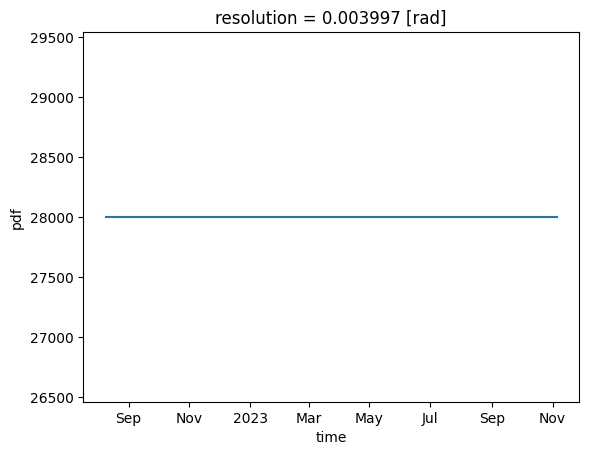

In [38]:
combined_all["pdf"].count(dims).plot()
print(f"PDF sum check: {combined_all.pdf.compute().sum().item():.4f}")


In [40]:
_out_path = f"{target_root}/emission_{emission_suffix}_pdf_{tag_name}.zarr"
combined_all.compute().to_zarr(
    _out_path,
    compute=True,
    mode="w",
    consolidated=True,
    zarr_version=2,
    storage_options=storage_options,
)
print(f"Saved to {_out_path}")


/home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 299.17 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/tmp/ipykernel_10978/1609920468.py:1: FutureWarning: zarr_version is deprecated, use zarr_format
  combined_all.compute().to_zarr(


Saved to s3://gfts-ifremer/tuna_mediterranean/run/capetienne/bbox/level10/global_copernicus/20P0204_larger_bbox1/emission_w_bathy_light_pdf_20P0204.zarr


## 9. Estimate the model parameters and decode trajectories

From here the workflow is identical to the standard `pangeo-fish` pipeline. The merged emission PDF is used as input to the HMM.


In [13]:
# Optional: open the baseline PDF (temperature-difference + bathymetry only).
# Useful to compare HMM output with and without light.
emission_baseline = xr.open_dataset(
    f"{target_root}/emission_w_bathy_pdf_{tag_name}.zarr",
    engine="zarr",
    chunks=default_chunk_dims,
    inline_array=True,
    storage_options=storage_options,
)

/tmp/ipykernel_2500/490492968.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  emission = xr.open_dataset(


<xarray.Dataset> Size: 158MB
Dimensions:     (cells: 42844, time: 454)
Coordinates:
    cell_ids    (cells) int64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    latitude    (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    longitude   (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    resolution  float64 8B ...
  * time        (time) datetime64[ns] 4kB 2022-08-09 2022-08-10 ... 2023-11-05
Dimensions without coordinates: cells
Data variables:
    final       (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    initial     (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    mask        (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    pdf         (time, cells) float64 156MB dask.array<chunksize=(1, 42844), meta=np.ndarray>
Attributes:
    comment:          pangeo-fish == 2025.3.4.dev20+g2e5c86fff.d20251210, hea...
    differences_std:  1.0
    grid_type:        healpix
    initial_std:      0.001
    lat:              0
    level:            8
    lon:              0
    min_vertices:     1
    nside:            256
    recapture_std:    0.001
    rot_lat:          0
    rot_lon:          0

In [14]:
# Open the full merged emission PDF.
# This is the input to the HMM.
emission = xr.open_dataset(
    f"{target_root}/emission_{emission_suffix}_pdf_{tag_name}.zarr",
    engine="zarr",
    chunks=default_chunk_dims,
    inline_array=True,
    storage_options=storage_options,
)
emission

/tmp/ipykernel_2500/3525796160.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  emission = xr.open_dataset(


<xarray.Dataset> Size: 153MB
Dimensions:     (cells: 41629, time: 454)
Coordinates:
    cell_ids    (cells) int64 333kB dask.array<chunksize=(41629,), meta=np.ndarray>
    latitude    (cells) float64 333kB dask.array<chunksize=(41629,), meta=np.ndarray>
    longitude   (cells) float64 333kB dask.array<chunksize=(41629,), meta=np.ndarray>
    resolution  float64 8B ...
  * time        (time) datetime64[ns] 4kB 2022-08-09 2022-08-10 ... 2023-11-05
Dimensions without coordinates: cells
Data variables:
    final       (cells) float64 333kB dask.array<chunksize=(41629,), meta=np.ndarray>
    initial     (cells) float64 333kB dask.array<chunksize=(41629,), meta=np.ndarray>
    mask        (cells) float64 333kB dask.array<chunksize=(41629,), meta=np.ndarray>
    pdf         (time, cells) float64 151MB dask.array<chunksize=(1, 41629), meta=np.ndarray>
Attributes:
    comment:          pangeo-fish == 2025.3.4.dev21+gcdd797eeb.d20260409, hea...
    differences_std:  1.0
    grid_type:        healpix
    initial_std:      0.001
    lat:              0
    level:            8
    lon:              0
    min_vertices:     1
    nside:            256
    recapture_std:    0.001
    rot_lat:          0
    rot_lon:          0

In [ ]:
from pangeo_fish.helpers import (
    _get_max_sigma,
    _get_package_versions,
    _get_predictor_factory,
    _update_params_dict,
    to_healpix, _s3_path_to_str
)
from pathlib import Path
from pangeo_fish.hmm.estimator import EagerEstimator
from pangeo_fish.hmm.optimize import EagerBoundsSearch

ds = emission.compute()
adjustment_factor = 5
truncate = 4
conv_method = "HealpixConv"


if "cells" in ds.dims and "cell_ids" not in ds.xindexes:
    ds = to_healpix(ds)
    as_radians = True


max_sigma = _get_max_sigma(
    ds, earth_radius, adjustment_factor, maximum_speed, as_radians
)
predictor_factory = _get_predictor_factory(
    ds=ds, truncate=truncate, dims=dims, conv_method=conv_method
)

estimator = EagerEstimator(sigma=None, predictor_factory=predictor_factory)
ds.attrs["max_sigma"] = max_sigma  # limitation of the helper

optimizer = EagerBoundsSearch(
    estimator,
    (1e-4, ds.attrs["max_sigma"]),
    optimizer_kwargs={"disp": 3, "xtol": tolerance},
)
optimized = optimizer.fit(ds)
params = optimized.to_dict()  # type: dict
params = _update_params_dict(factory=predictor_factory, params=params)
params.update(_get_package_versions())

path_to_json = Path(target_root) / "parameters_with_light.json"

In [11]:
import pandas as pd
if storage_options is None:
    path_to_json.parent.mkdir(parents=True, exist_ok=True)
    str_path_to_json = str(path_to_json)
else:
    str_path_to_json = _s3_path_to_str(path_to_json)
    pd.DataFrame.from_dict(params, orient="index").to_json(
    str_path_to_json, storage_options=storage_options
    )

In [19]:
import pandas as pd
from pangeo_fish.helpers import _get_predictor_factory
from pangeo_fish.hmm.estimator import EagerEstimator

emission = emission.dggs.decode(
    {"grid_name": "healpix", "level": 8, "indexing_scheme": "nested"}
)
emission = emission.compute()

params = pd.read_json(
    f"{target_root}/parameters_with_light.json", storage_options=storage_options
).to_dict()[0]

# do not account for the other kwargs...
# not very robust yet...
predictor_kwargs = params["predictor_factory"].get("kwargs", {})

truncate_raw = predictor_kwargs.get("truncate")
truncate = float(truncate_raw) if truncate_raw is not None else None

cls_name = params["predictor_factory"]["class"]  # type: str
if "Gaussian1DHealpix" in cls_name:
    predictor_factory = _get_predictor_factory(
        emission, truncate=truncate, conv_method="HealpixConv", dims=["cells"]
    )
else:
    raise RuntimeError("Could not infer predictor's class from the `.json` file.")

optimized = EagerEstimator(sigma=params["sigma"], predictor_factory=predictor_factory)

states = optimized.predict_proba(emission.compute())
states = (
    states.to_dataset()
    .chunk(default_chunk_dims)
    .assign_attrs(emission.attrs | {"sigma": params["sigma"]})
)  # type: xr.Dataset

states.compute().to_zarr(
    f"{target_root}/states_with_light.zarr",
    compute=True,
    mode="w",
    consolidated=True,
    zarr_version=2,
    storage_options=storage_options,
)

Backward: 100%|██████████| 453/453 [01:08<00:00,  6.64it/s]
/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 145.16 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/tmp/ipykernel_2500/3507164698.py:38: FutureWarning: zarr_version is deprecated, use zarr_format
  states.compute().to_zarr(


In [18]:
states = states.dggs.decode(
    {"grid_name": "healpix", "level": 8, "indexing_scheme": "nested"}
)
states.states.compute().dggs.explore()

/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 145.16 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [20]:
%%time
from pangeo_fish.helpers import predict_positions

states, trajectories = predict_positions(
    ds=emission.compute().dggs.decode(
        {"grid_name": "healpix", "level": 8, "indexing_scheme": "nested"}
    ),
    target_root=target_root,
    storage_options=storage_options,
    chunks=default_chunk_dims,
    track_modes=track_modes,
    additional_track_quantities=additional_track_quantities,
    save=True,
    tag_name=tag_name,
)

Backward: 100%|██████████| 453/453 [01:40<00:00,  4.52it/s]
/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 145.29 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 146.32 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sendi

CPU times: user 2min 47s, sys: 55.8 s, total: 3min 43s
Wall time: 3min 57s


In [21]:
states = states.dggs.decode(
    {"grid_name": "healpix", "level": 8, "indexing_scheme": "nested"}
)
states.states.compute().dggs.explore()

/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 145.16 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [22]:
states.compute().to_zarr(
    f"{target_root}/states.zarr",
    compute=True,
    mode="w",
    consolidated=True,
    zarr_version=2,
    storage_options=storage_options,
)

/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 145.16 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/tmp/ipykernel_2500/2827736986.py:1: FutureWarning: zarr_version is deprecated, use zarr_format
  states.compute().to_zarr(


In [24]:
states = xr.open_dataset(f"{target_root}/states_with_light.zarr", engine="zarr")
trajectories = optimized.decode(
    emission,
    states.fillna(0),
    mode=track_modes,
    progress=False,
    additional_quantities=additional_track_quantities,
)


def save_trajectories(traj, root, storage_options=None, format="geoparquet"):
    from pangeo_fish.tracks import to_dataframe

    converters = {
        "geoparquet": lambda x: x.drop(columns="traj_id"),
        "parquet": to_dataframe,
    }
    converter = converters.get(format)
    if converter is None:
        raise ValueError(f"unknown format: {format!r}")

    if not isinstance(root, str):
        root = str(root)

    trajectories = getattr(traj, "trajectories", [traj])

    for traj in trajectories:
        print(f"{root}/{traj.id}_w_light.parquet")
        path = f"{root}/{traj.id}_w_light.parquet"

        df = converter(traj.df)
        df.to_parquet(path, storage_options=storage_options)


save_trajectories(trajectories, target_root, storage_options, format="parquet")

s3://gfts-ifremer/tuna_mediterranean/run/capetienne/bbox/level10/global_copernicus/20P0204_larger_bbox1/mean_no_light.parquet
s3://gfts-ifremer/tuna_mediterranean/run/capetienne/bbox/level10/global_copernicus/20P0204_larger_bbox1/mode_no_light.parquet


# VIZ medit

In [25]:
from pangeo_fish.helpers import plot_trajectories

In [27]:
plot = plot_trajectories(
    target_root=target_root,
    track_modes=["mean_w_light","mean_no_light"],
    storage_options=storage_options,
    save_html=True,
)
plot

:Layout
   .Overlay.I  :Overlay
      .WMTS.I   :WMTS   [Longitude,Latitude]
      .Path.I   :Path   [Longitude,Latitude]   (speed)
      .Points.I :Points   [Longitude,Latitude]   (speed,triangle_angle)
   .Overlay.II :Overlay
      .WMTS.I   :WMTS   [Longitude,Latitude]
      .Path.I   :Path   [Longitude,Latitude]   (speed)
      .Points.I :Points   [Longitude,Latitude]   (speed,triangle_angle)